In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os
sys.path.insert(0, os.environ['PLOT_SETTINGS_DIR'])
import plot_settings

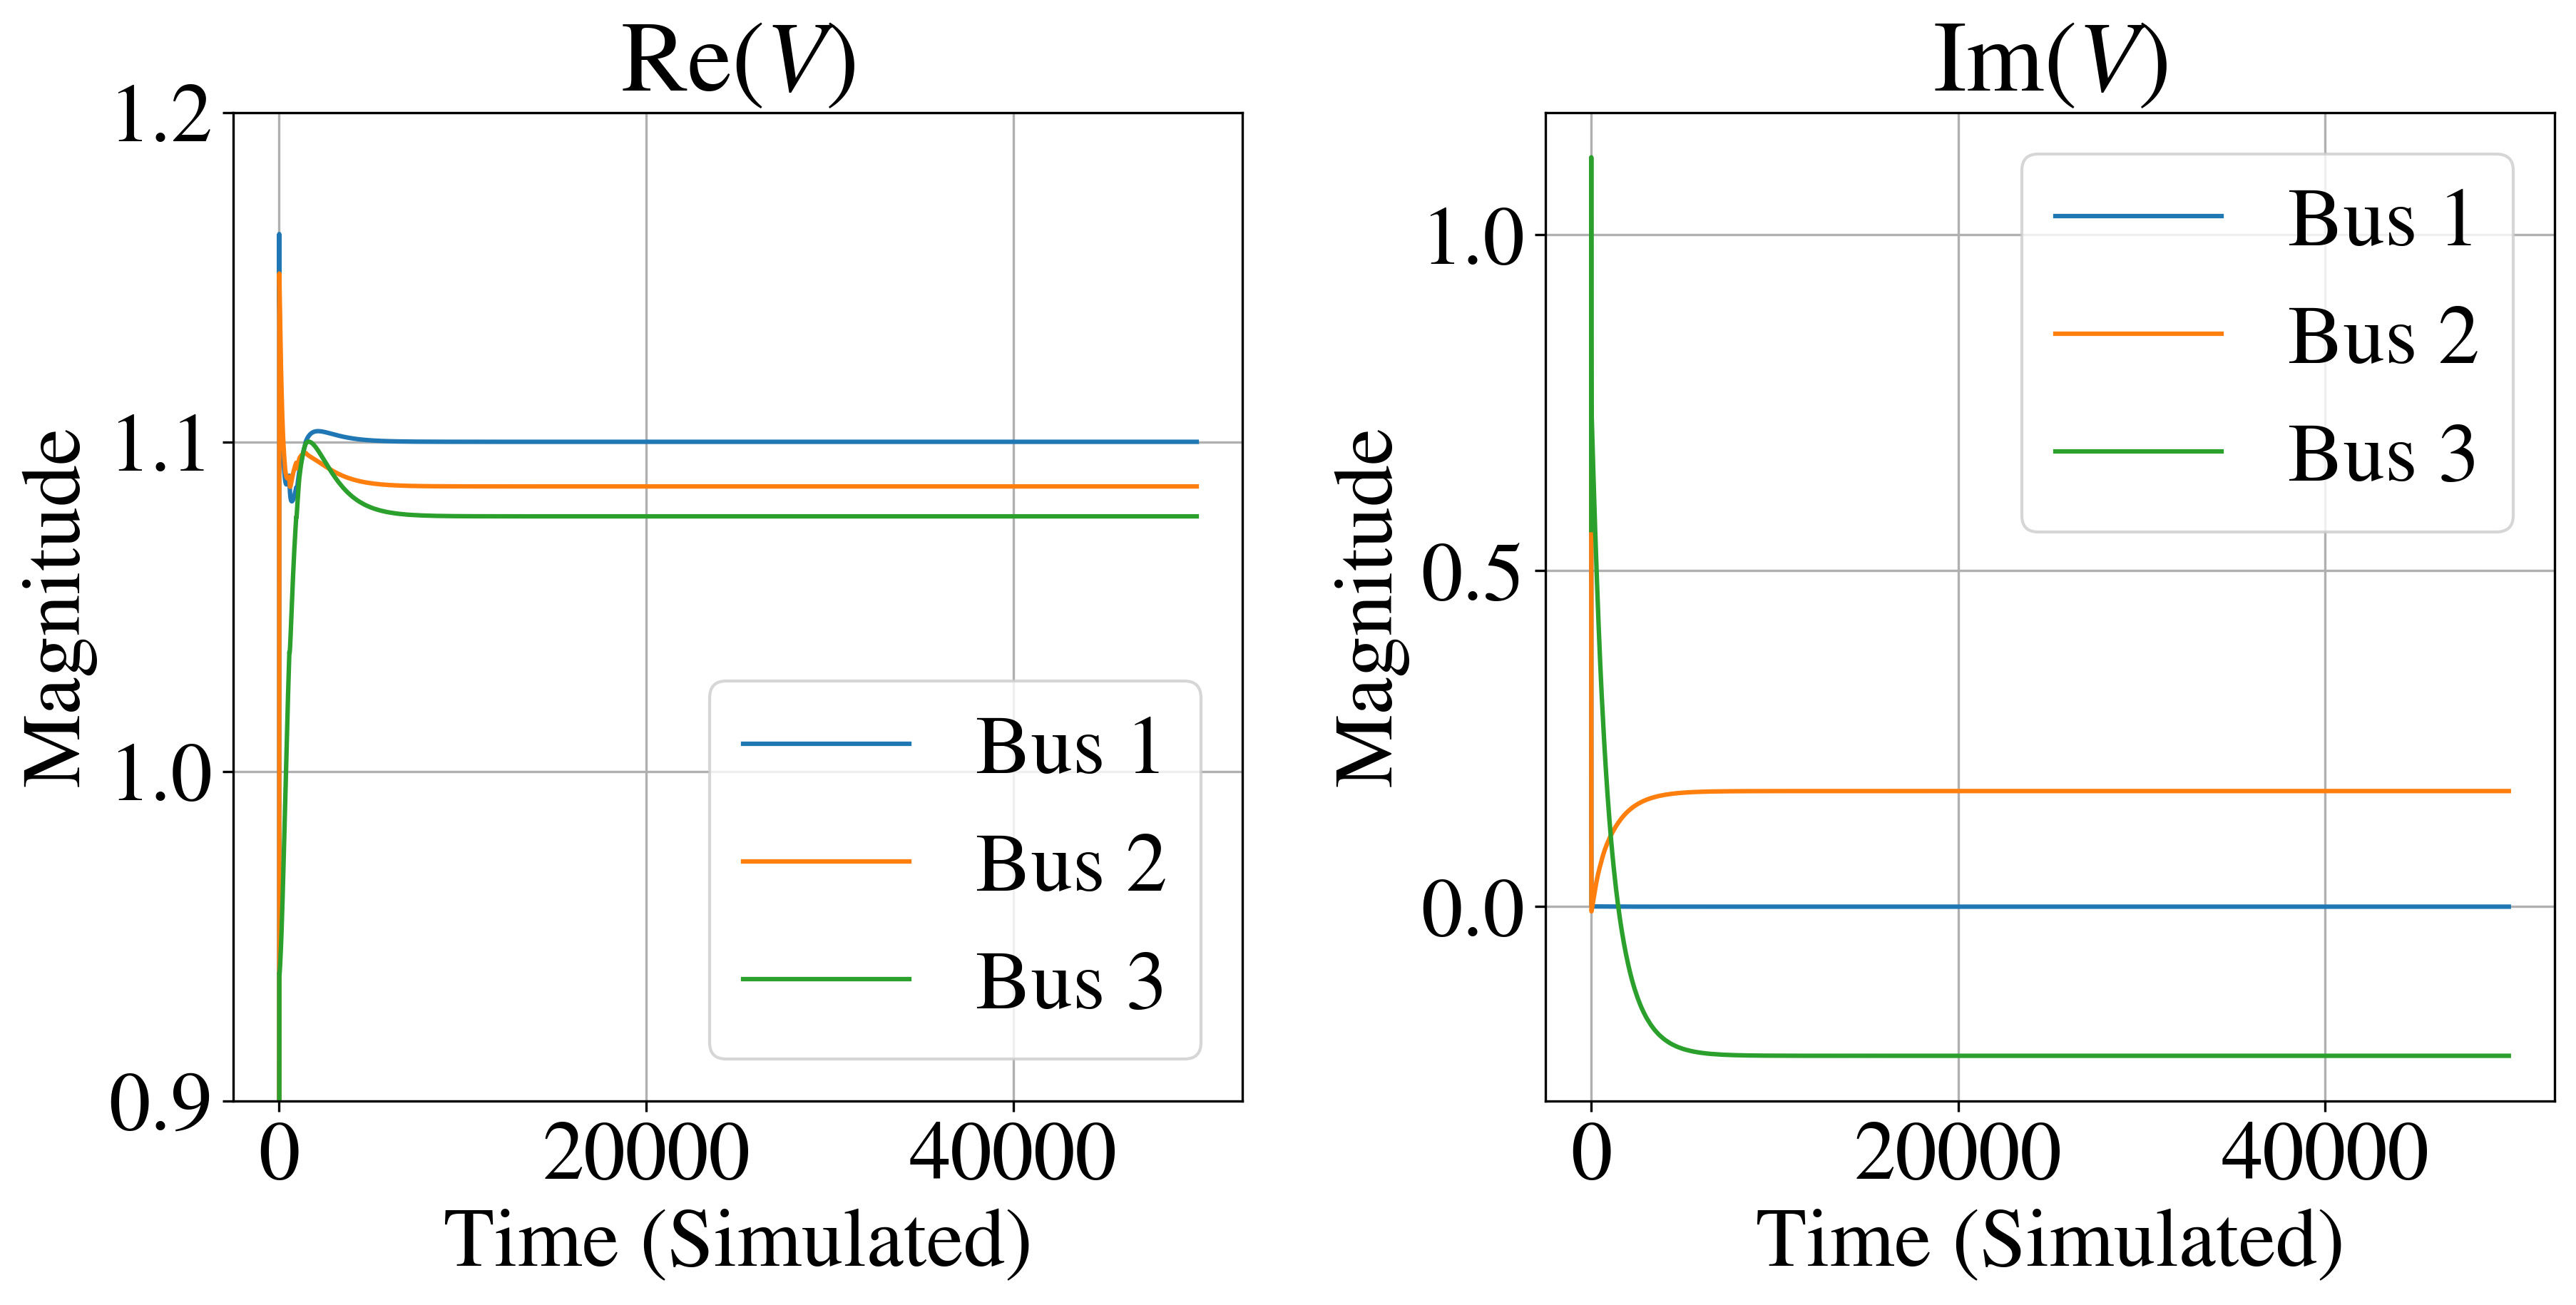

In [3]:
n = 3
viz_3 = pd.read_csv(f'data/case_{n}_bits_0_false_results.csv')
fig, axs = plt.subplots(ncols=2, figsize=(14,6), gridspec_kw=dict(wspace=0.3))
ax = axs[0]
for i in range(1,n+1):
    sns.lineplot(ax=ax, data=viz_3, x='t', y=f'v{i}', label=f'Bus {i}')
ax = axs[1]
for i in range(1,n+1):
    sns.lineplot(ax=ax, data=viz_3, x='t', y=f'v{i+n}', label=f'Bus {i}')
axs[0].set_ylim(0.9, 1.2)
for ax in axs:
    ax.grid()
    ax.set_xlabel("Time (Simulated)")
axs[0].set_ylabel('Magnitude')
axs[1].set_ylabel('Magnitude')
axs[0].set_title(r"$\text{Re}(V)$")
axs[1].set_title(r"$\text{Im}(V)$")
fig.savefig(f"data/case_{n}_variables.pdf", bbox_inches='tight')
    # ax.set_xscale('log')

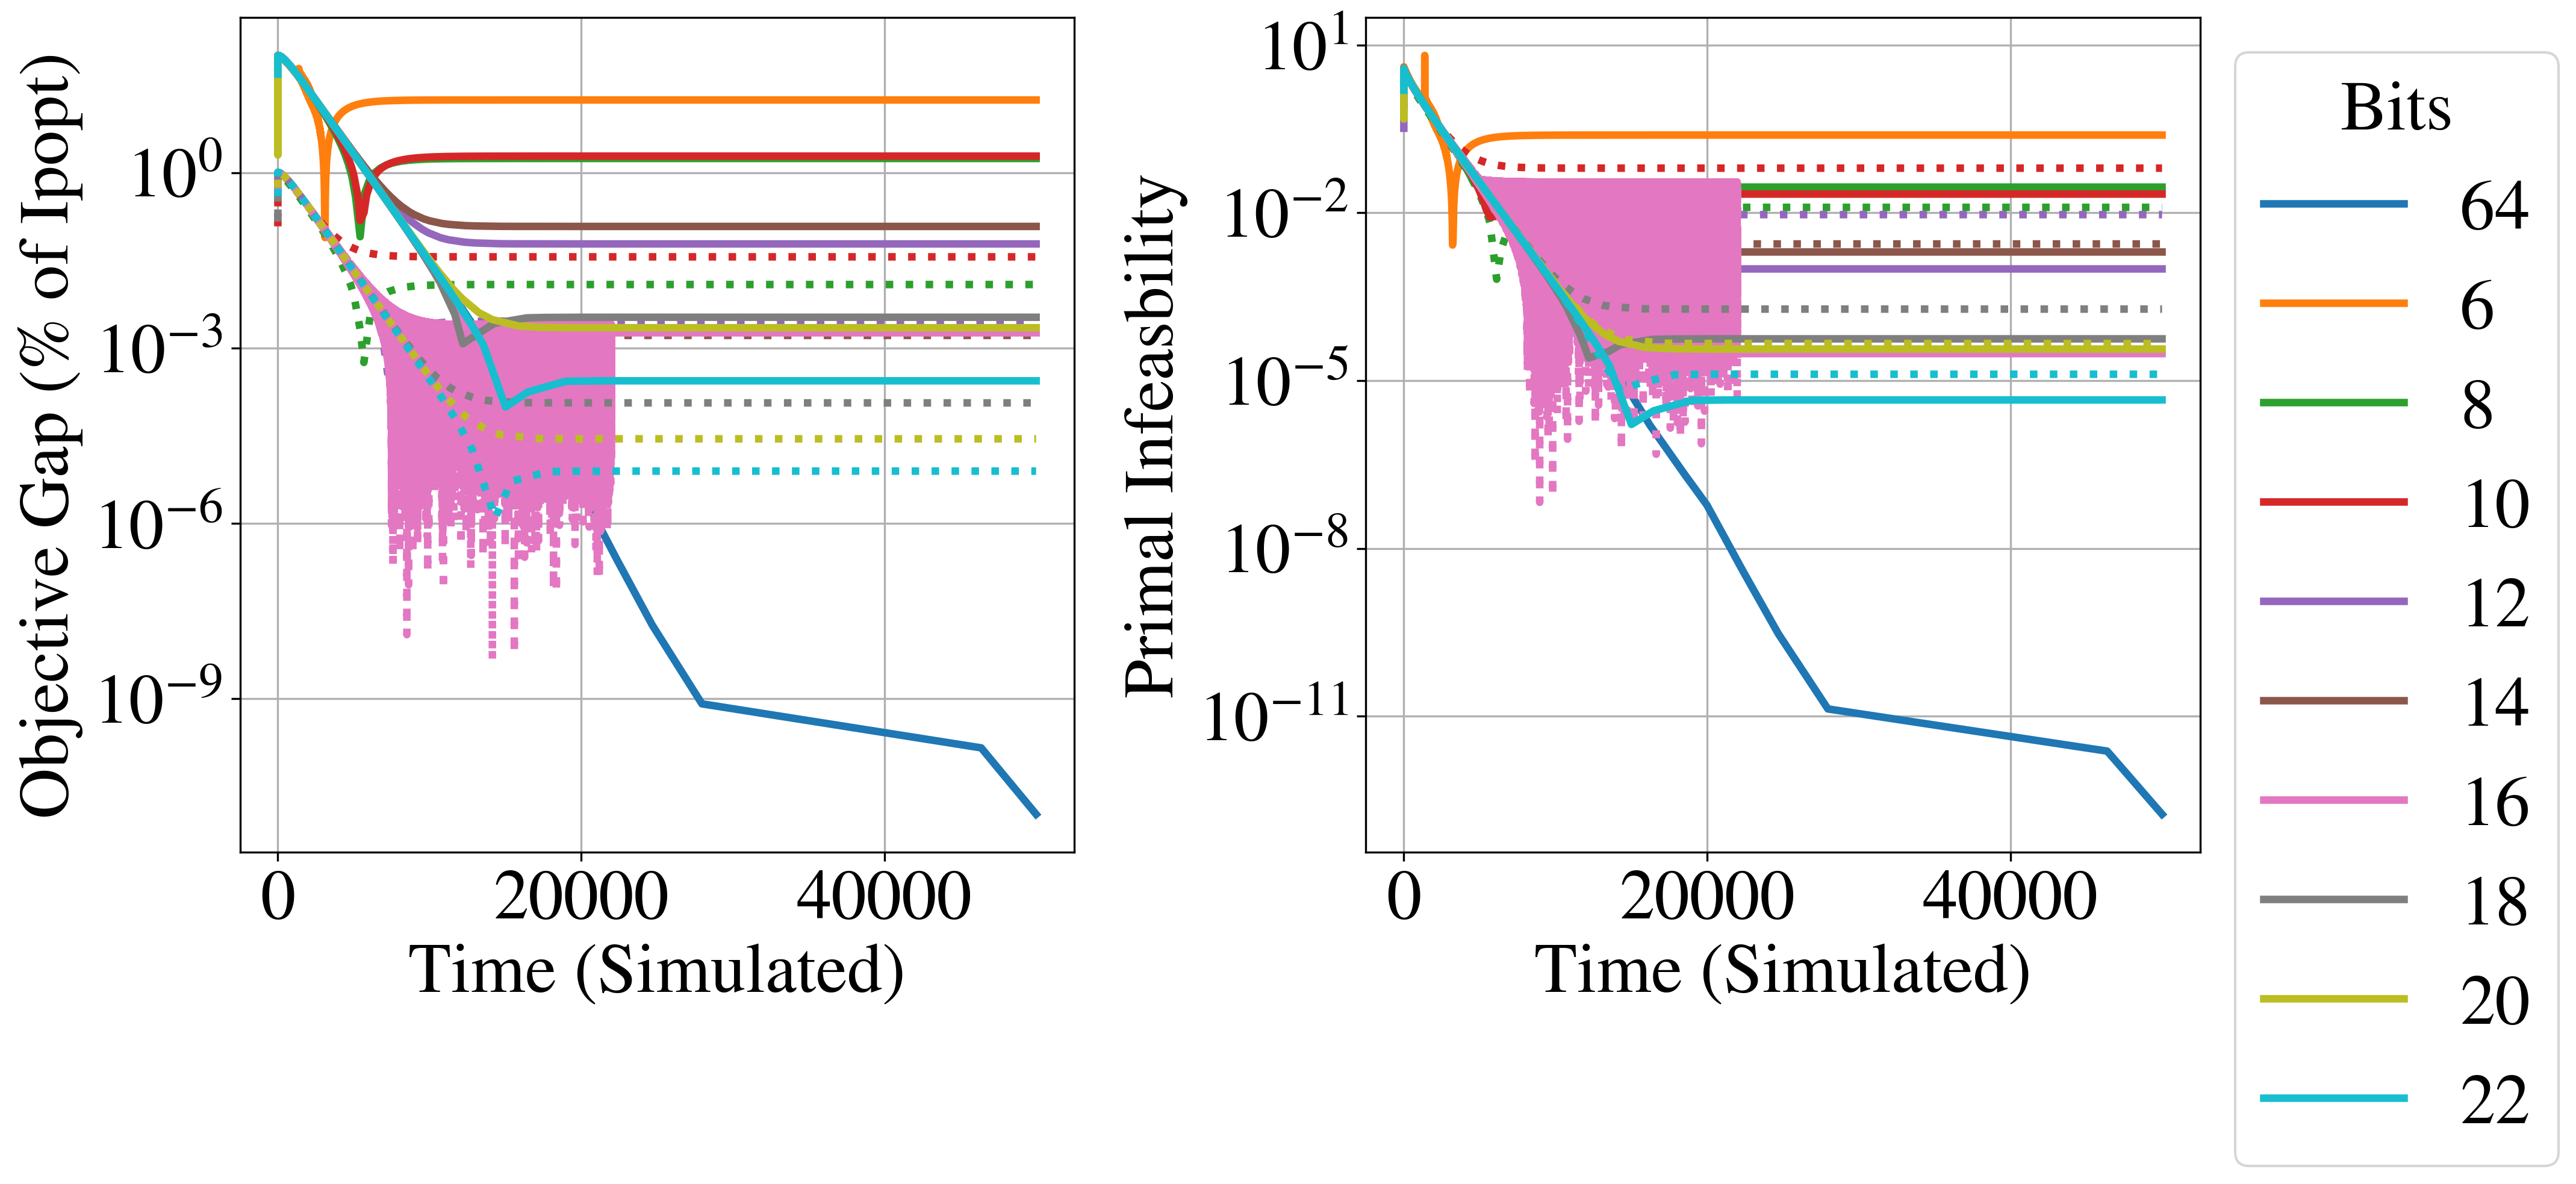

/tmp/ipykernel_106827/2442112706.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(title='Randomized', loc='upper left', bbox_to_anchor=(1,1))


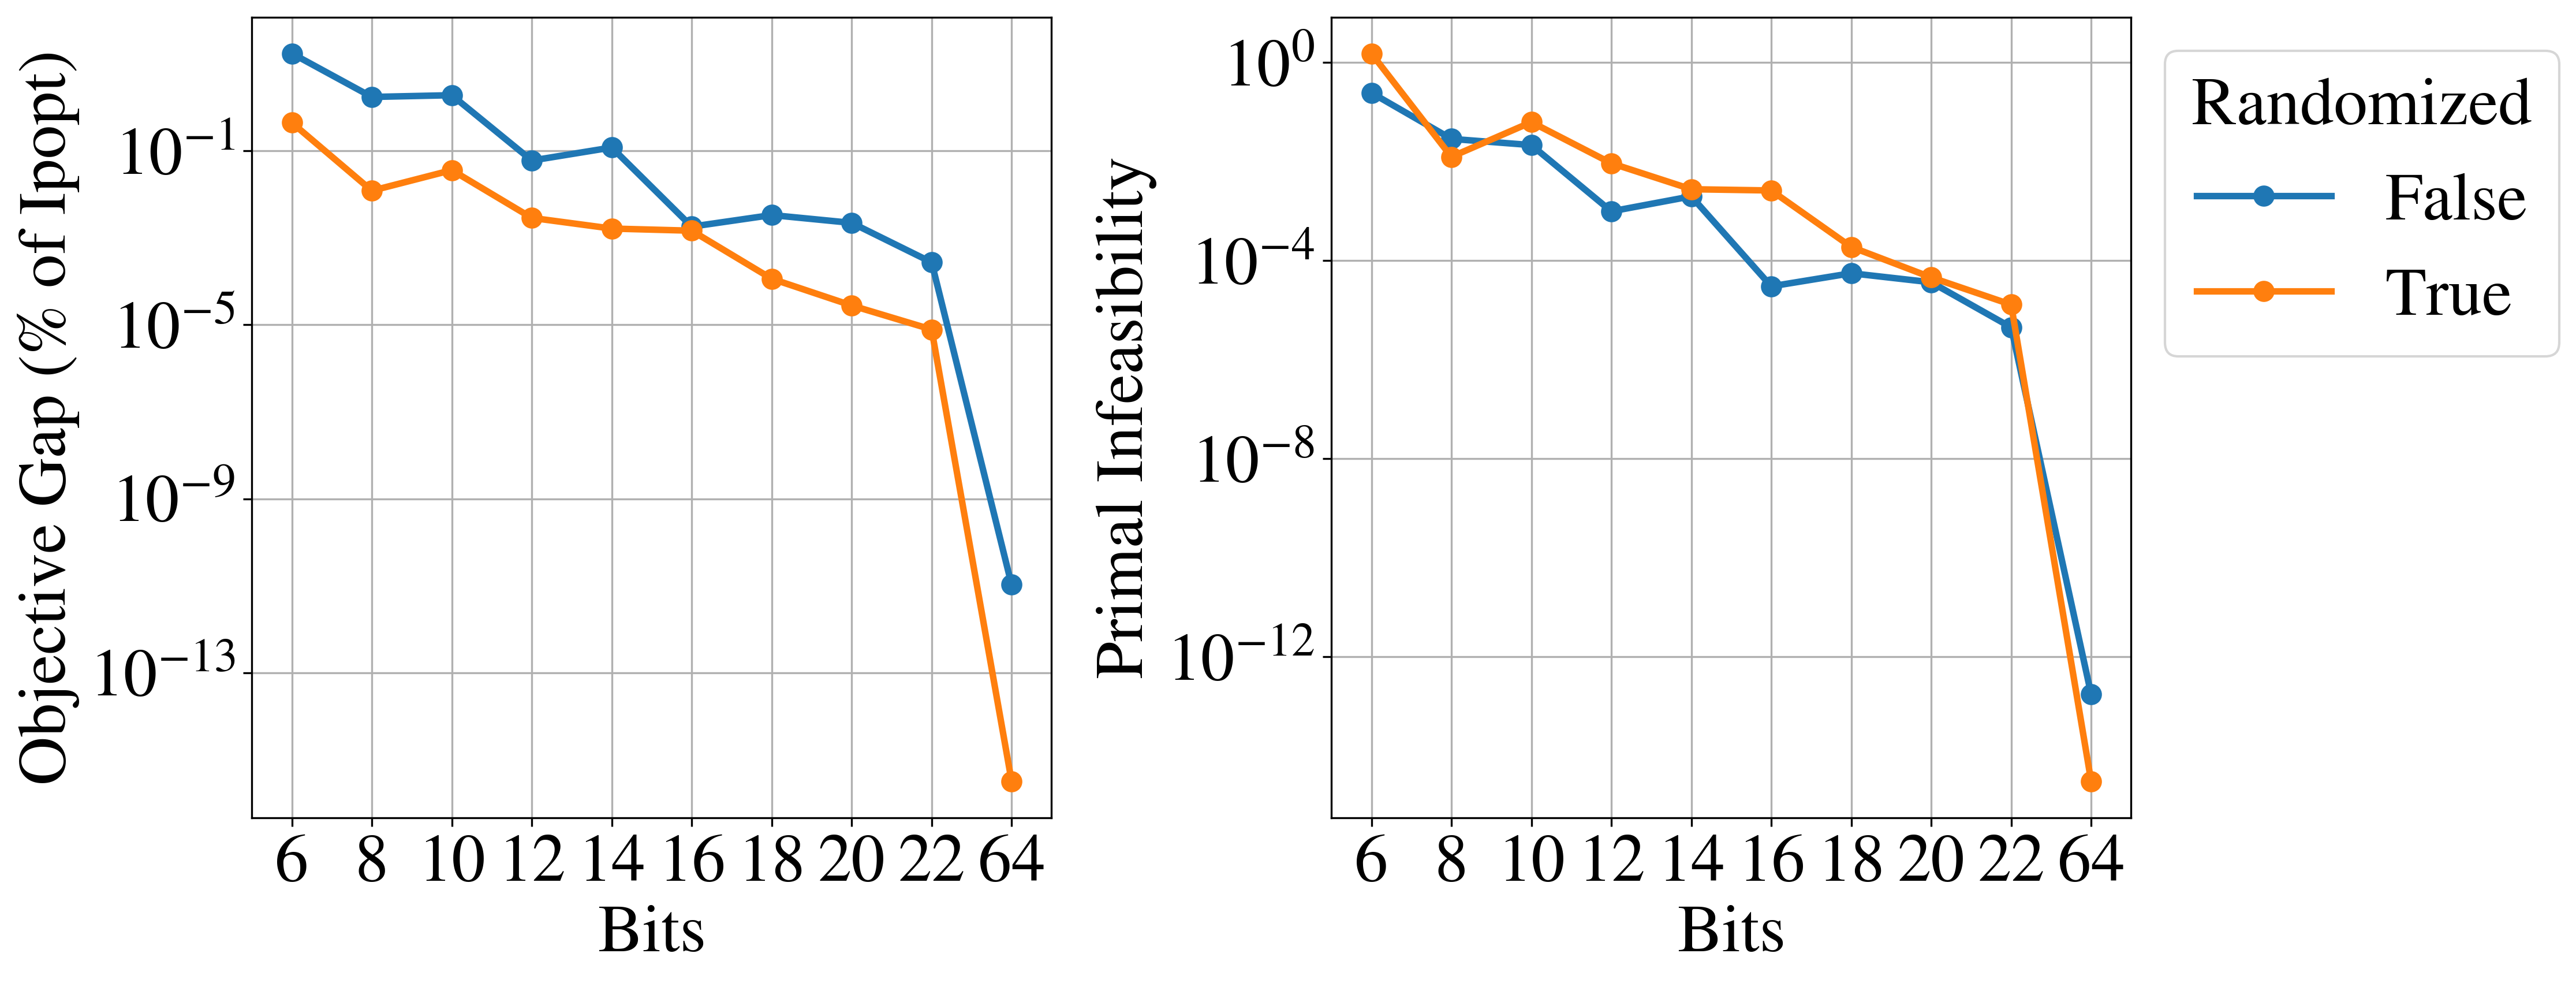

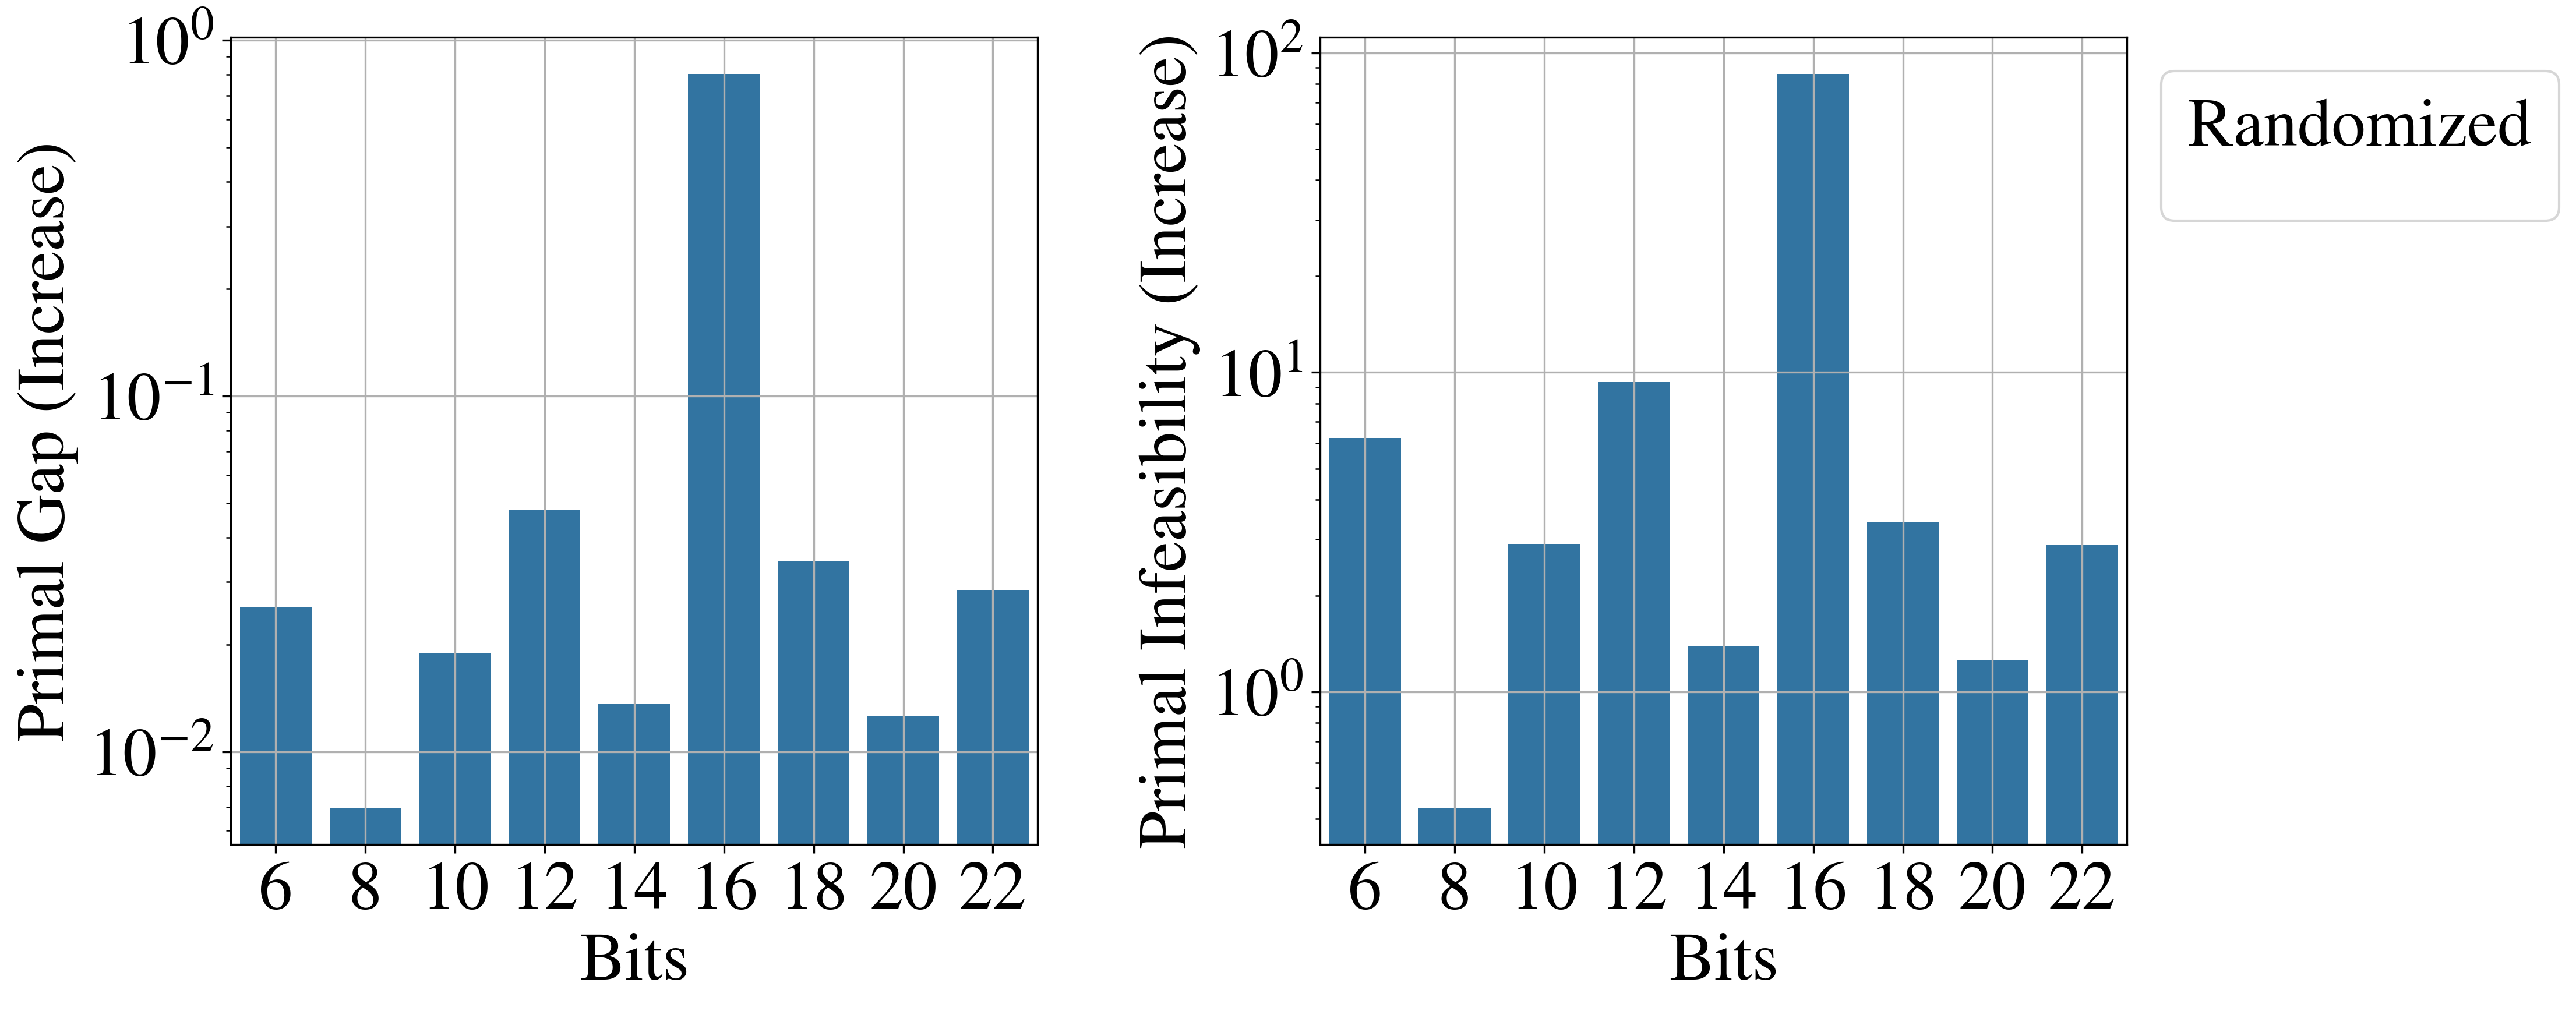

In [4]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw=dict(wspace=0.35))
last_data = []
for i, bits in enumerate([0, 6,8, 10, 12, 14, 16, 18, 20, 22]):
    palette = sns.color_palette()
    viz_3 = pd.read_csv(f'data/case_{n}_bits_{bits}_false_results.csv')
    viz_3['Primal Gap'] = np.abs(viz_3['objective'] - 5694.536576127584) / 5694.536576127584 * 100
    sns.lineplot(ax=axs[0], data=viz_3, x='t', y='Primal Gap', zorder=2, linestyle='solid', linewidth=3, color=palette[i])
    sns.lineplot(ax=axs[1], data=viz_3, x='t', y='primal_feasibility', label=f'{bits}' if bits != 0 else r'64', linestyle='solid', linewidth=3, color=palette[i])
    last_data.append([False, bits if bits != 0 else 64, viz_3['Primal Gap'].iloc[-1], viz_3['primal_feasibility'].iloc[-1]])
    viz_3 = pd.read_csv(f'data/case_{n}_bits_{bits}_true_results.csv')
    viz_3['Primal Gap'] = np.abs(viz_3['objective'] - 5694.536576127584) / 5694.536576127584
    last_data.append([True, bits if bits != 0 else 64, viz_3['Primal Gap'].iloc[-1], viz_3['primal_feasibility'].iloc[-1]])
    if bits == 6 or bits == 0:
        continue
    sns.lineplot(ax=axs[0], data=viz_3, x='t', y='Primal Gap', zorder=2, linestyle='dotted', linewidth=3, color=palette[i])
    sns.lineplot(ax=axs[1], data=viz_3, x='t', y='primal_feasibility', linestyle='dotted', linewidth=3, color=palette[i])

axs[0].set_ylabel('Objective Gap (% of Ipopt)')
axs[0].set_xlabel("Time (Simulated)")
axs[1].set_ylabel("Primal Infeasbility")
axs[1].set_xlabel("Time (Simulated)")
axs[1].set_yscale("log")
axs[0].set_yscale("log")
axs[0].grid()
axs[1].legend(title='Bits', loc='upper left', bbox_to_anchor=(1,1))
axs[1].grid()
plt.show()
fig.savefig(f"case_{n}_objective.pdf", bbox_inches='tight')
comp_df = pd.DataFrame(last_data, columns=['Randomized', 'Bits', 'Primal Gap', 'Primal Infeasibility'])
fig, axs = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw=dict(wspace=0.35))
sns.pointplot(comp_df, ax=axs[0], x='Bits', y='Primal Gap', hue='Randomized', legend=False)

axs[0].set_ylabel('Objective Gap (% of Ipopt)')
axs[0].set_yscale('log')
sns.pointplot(comp_df, ax=axs[1], x='Bits', y='Primal Infeasibility', hue='Randomized')
axs[1].legend(title='Randomized', loc='upper left', bbox_to_anchor=(1,1))
axs[0].grid()
axs[1].grid()
axs[1].set_yscale('log')
fig.savefig(f"case_{n}_comparison.pdf", bbox_inches='tight')
fig, axs = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw=dict(wspace=0.35))
rand_df = comp_df.query("Randomized == True and Bits < 64")
fixed_df = comp_df.query("Randomized == False and Bits < 64")
comp_df2 = rand_df.merge(fixed_df, on=['Bits'], suffixes=['_rand', '_fixed'])
comp_df2['Primal Gap (Increase)'] = comp_df2['Primal Gap_rand'] / comp_df2['Primal Gap_fixed'] 
comp_df2['Primal Infeasibility (Increase)'] = comp_df2['Primal Infeasibility_rand'] / comp_df2['Primal Infeasibility_fixed'] 
sns.barplot(comp_df2, ax=axs[0], x='Bits', y='Primal Gap (Increase)', legend=False)
axs[0].set_yscale('log')
sns.barplot(comp_df2, ax=axs[1], x='Bits', y='Primal Infeasibility (Increase)')
axs[1].legend(title='Randomized', loc='upper left', bbox_to_anchor=(1,1))
axs[0].grid()
axs[1].grid()
axs[1].set_yscale('log')
fig.savefig(f"case_{n}_comparison_rand.pdf", bbox_inches='tight')

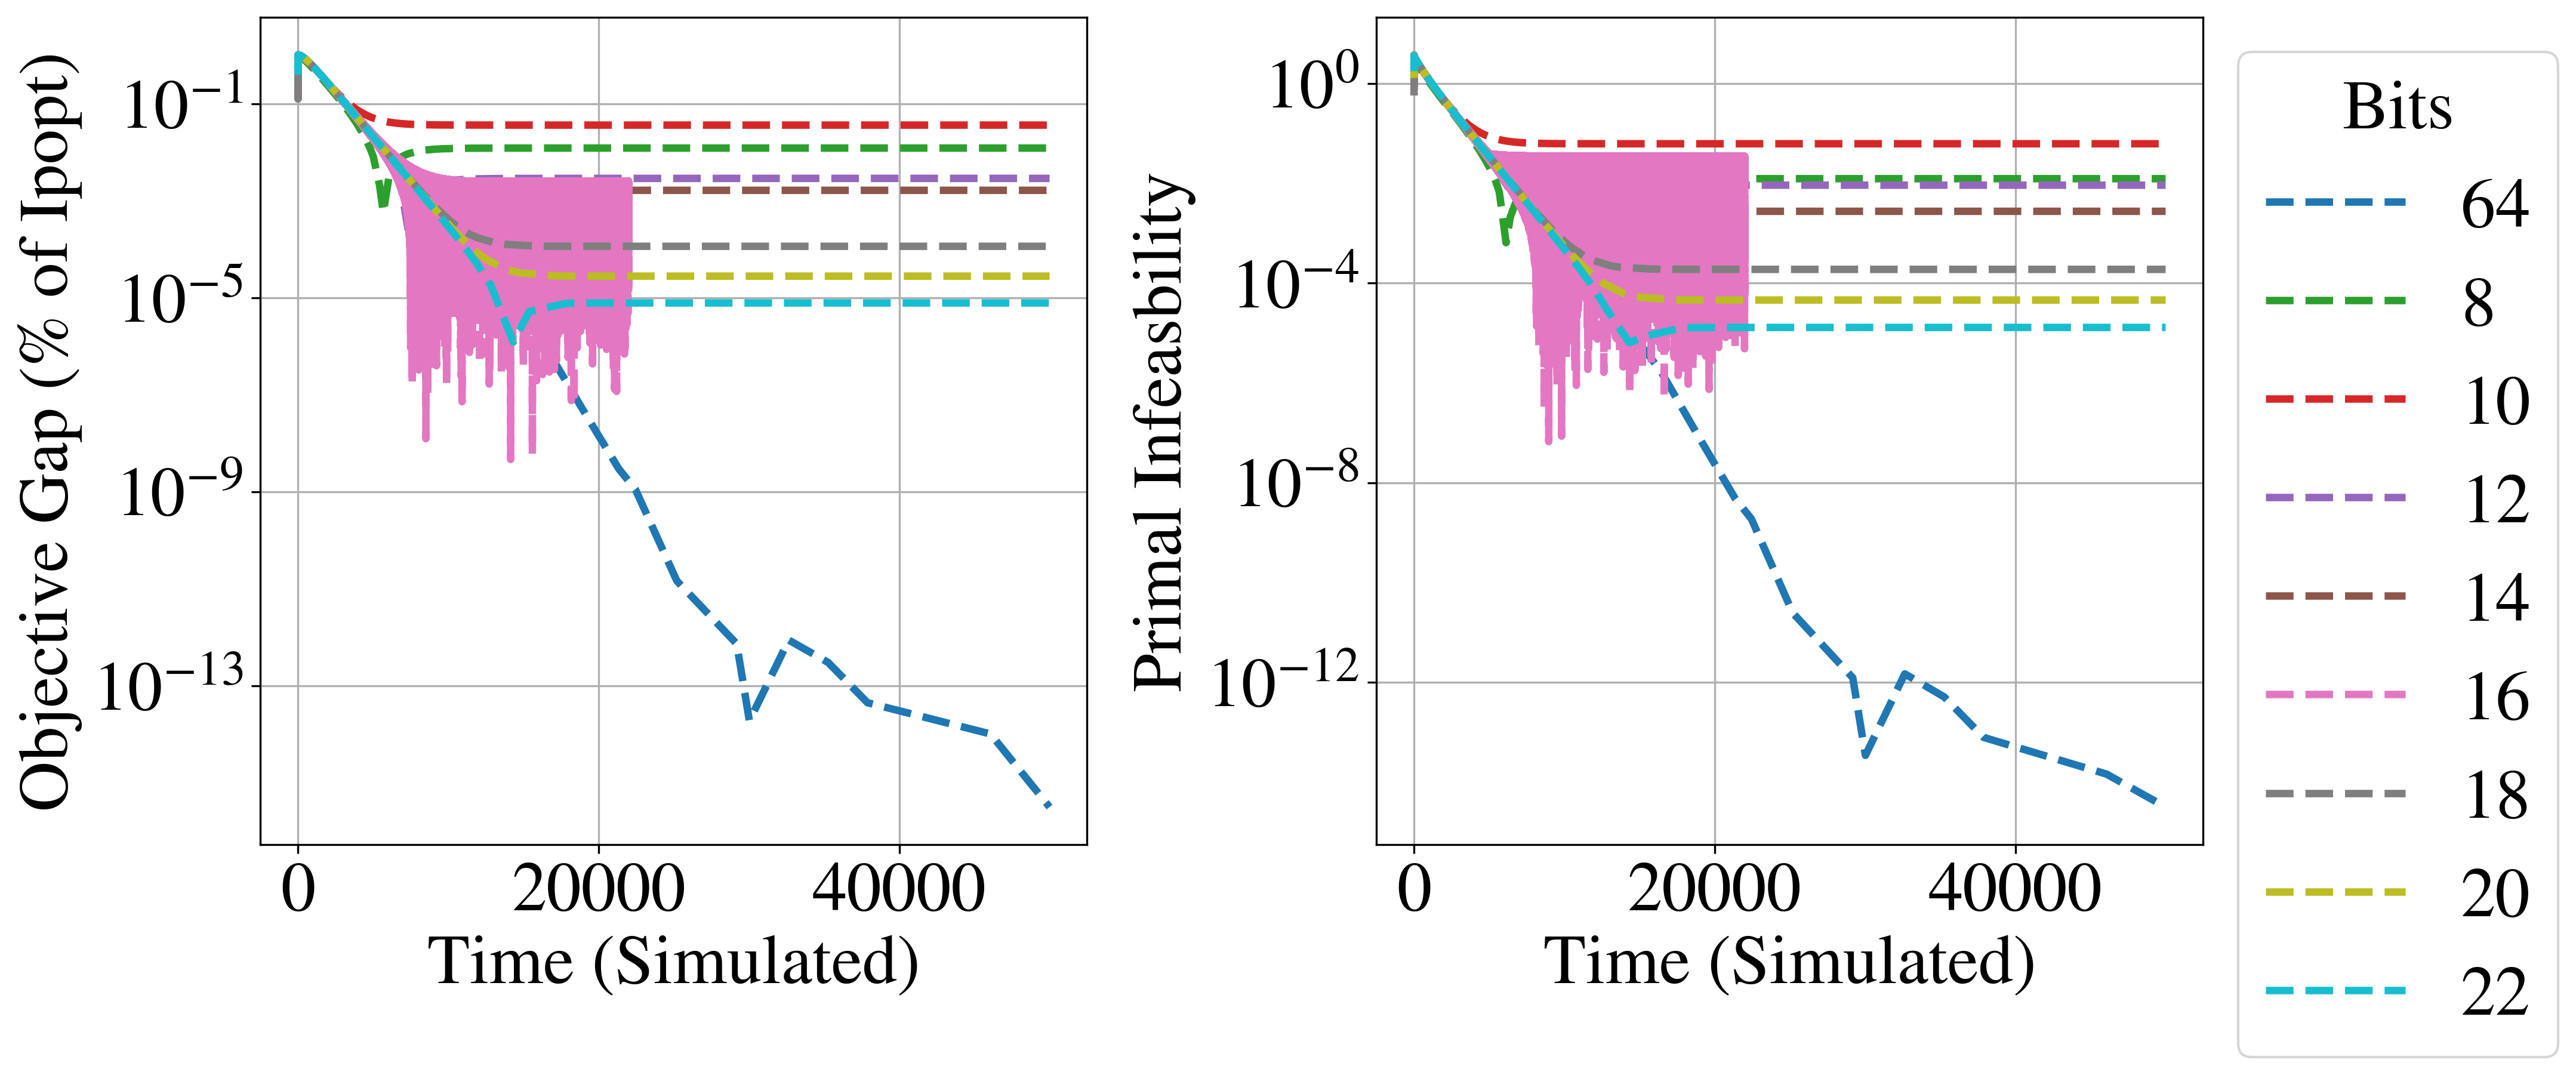

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw=dict(wspace=0.35))
palette = sns.color_palette()
for i, bits in enumerate([0, 6,8, 10, 12, 14, 16, 18, 20, 22]):
    viz_3 = pd.read_csv(f'data/case_{n}_bits_{bits}_true_results.csv')
    if bits == 6:
        continue
    viz_3['Primal Gap'] = np.abs(viz_3['objective'] - 5694.536576127584) / 5694.536576127584
    sns.lineplot(ax=axs[0], data=viz_3, x='t', y='Primal Gap', zorder=2, linestyle='--', linewidth=3, color=palette[i])
    sns.lineplot(ax=axs[1], data=viz_3, x='t', y='primal_feasibility', label=f'{bits}' if bits != 0 else r'64', linestyle='--', linewidth=3, color=palette[i])
axs[0].set_ylabel('Objective Gap (% of Ipopt)')
axs[0].set_xlabel("Time (Simulated)")
axs[1].set_ylabel("Primal Infeasbility")
axs[1].set_xlabel("Time (Simulated)")
axs[1].set_yscale("log")
axs[0].set_yscale("log")
axs[0].grid()
axs[1].legend(title='Bits', loc='upper left', bbox_to_anchor=(1,1))
axs[1].grid()
plt.show()
fig.savefig(f"data/case_{n}_objective_random.pdf", bbox_inches='tight')


Index(['benchmark', 'bits', 'distance', 'dual_status', 'ipopt_objective',
       'objective', 'primal_status', 'random', 'time', 'variables',
       'constraints', 'gap'],
      dtype='object')


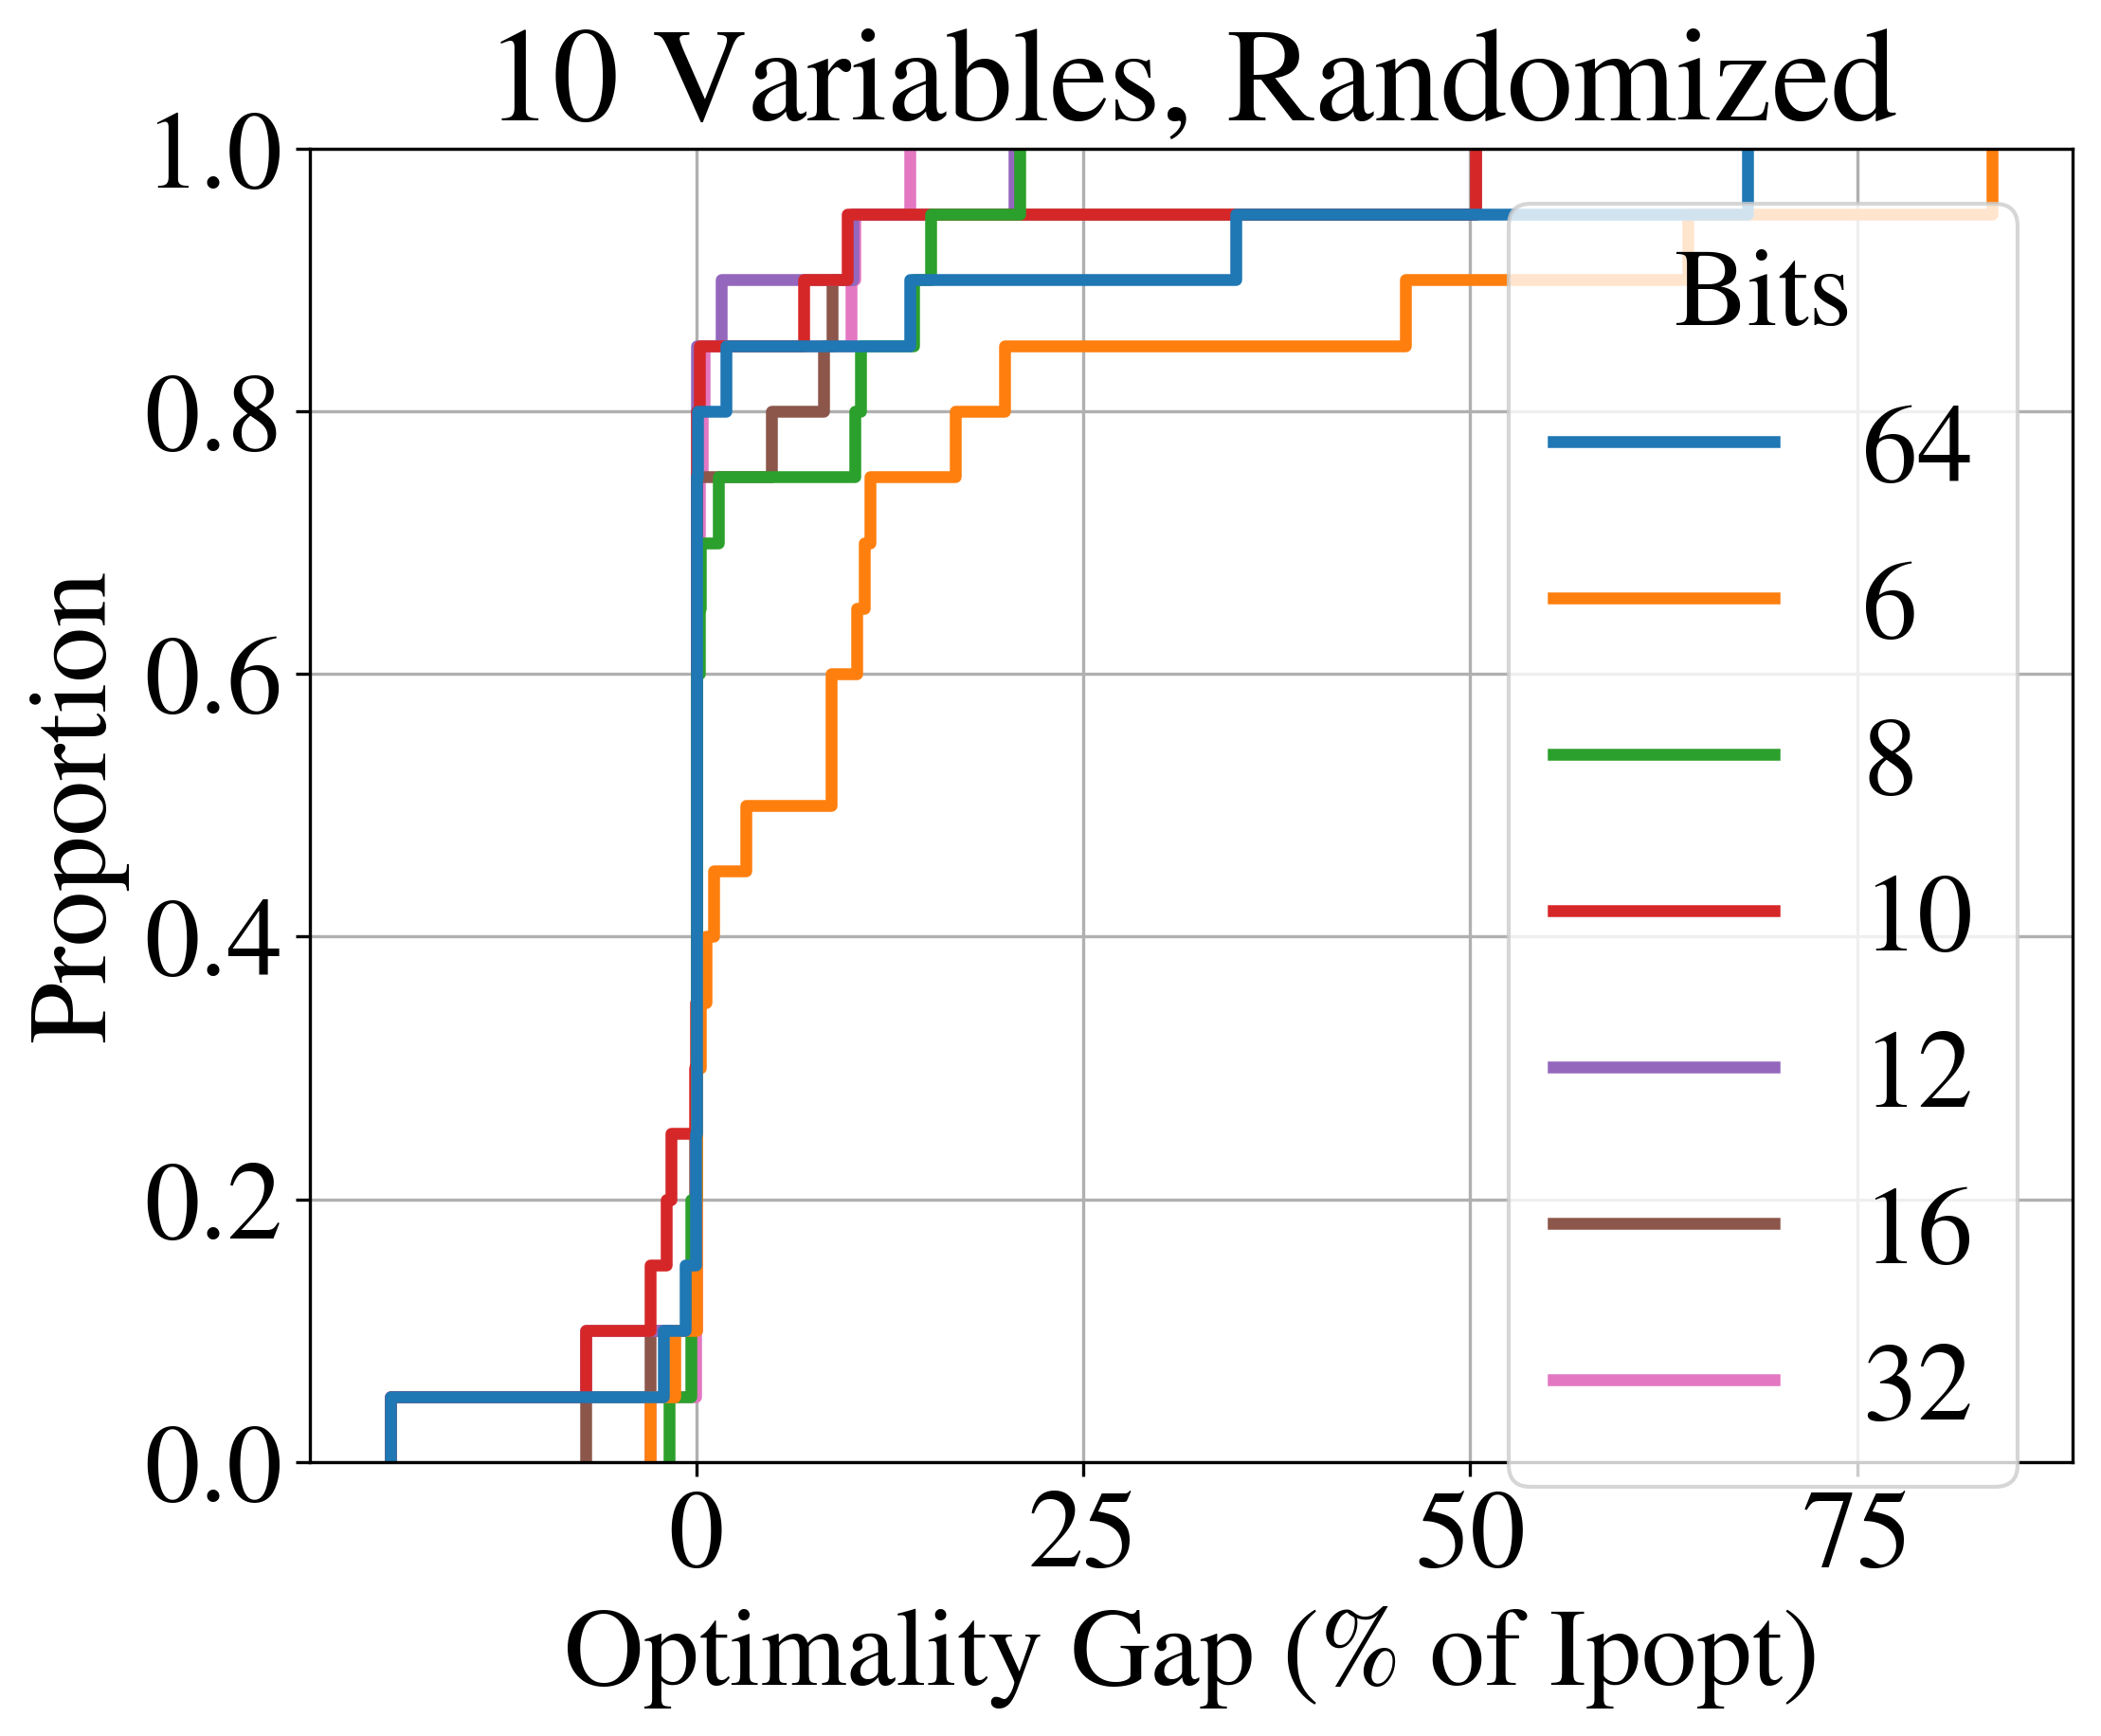

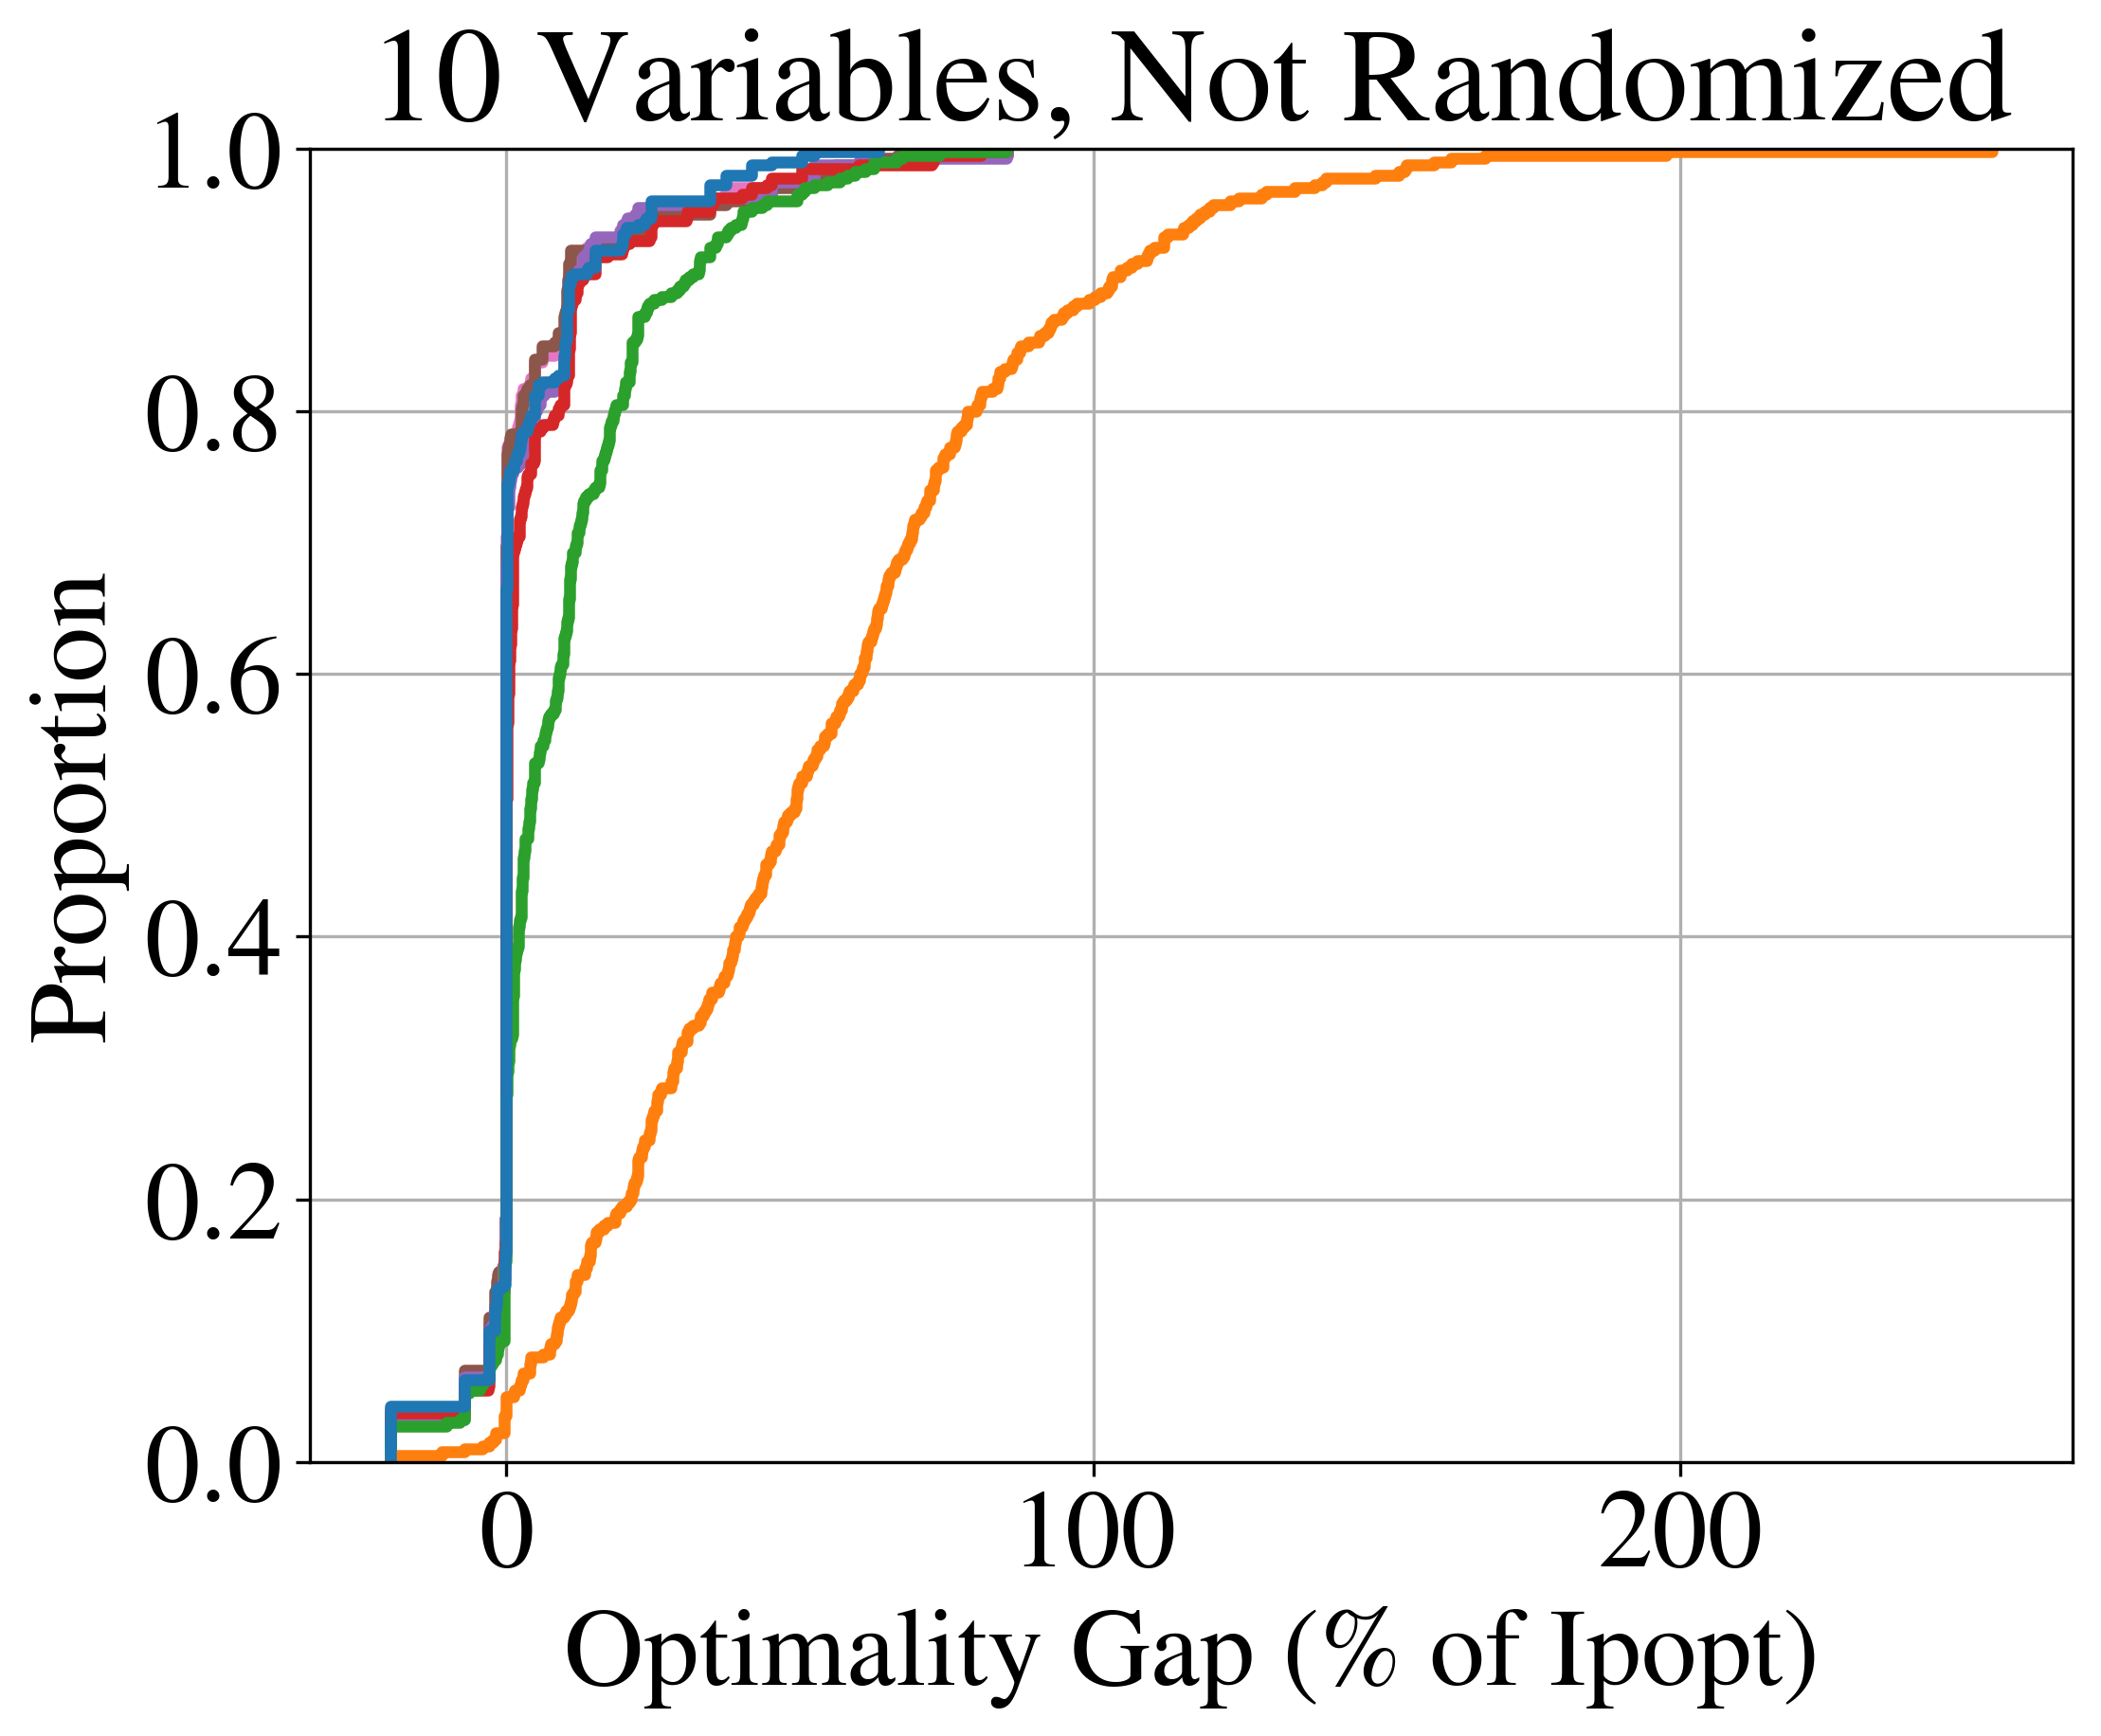

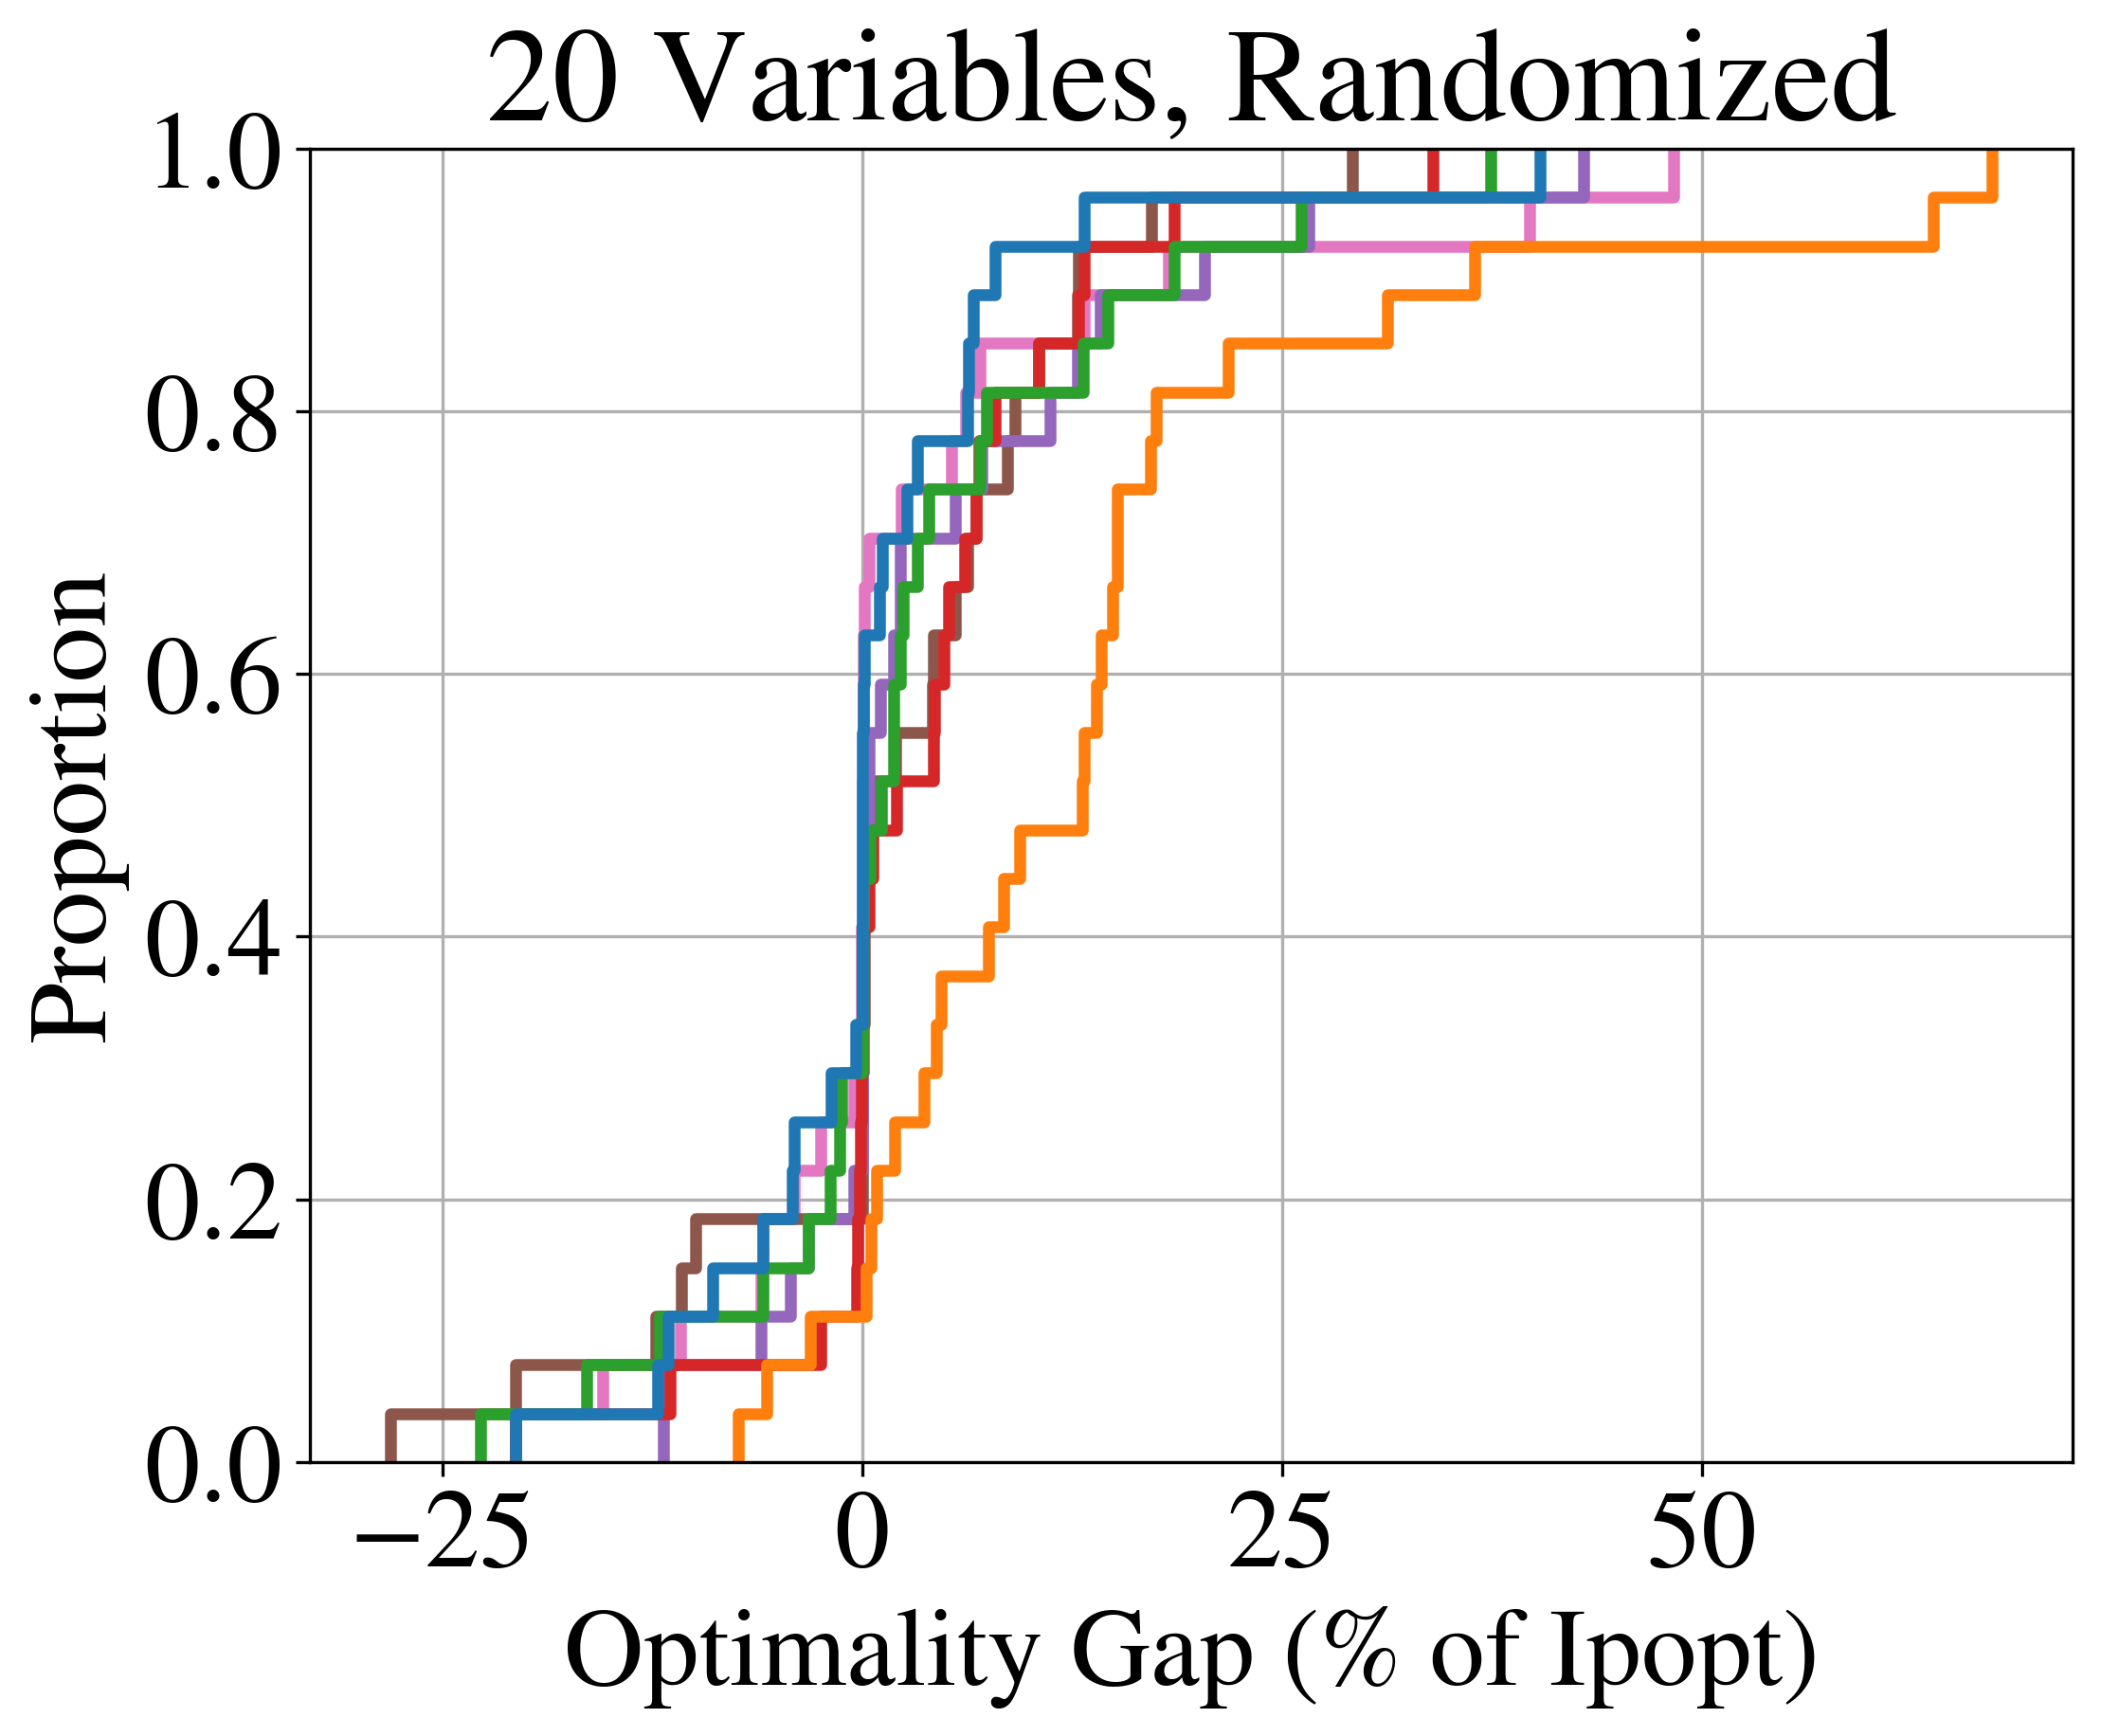

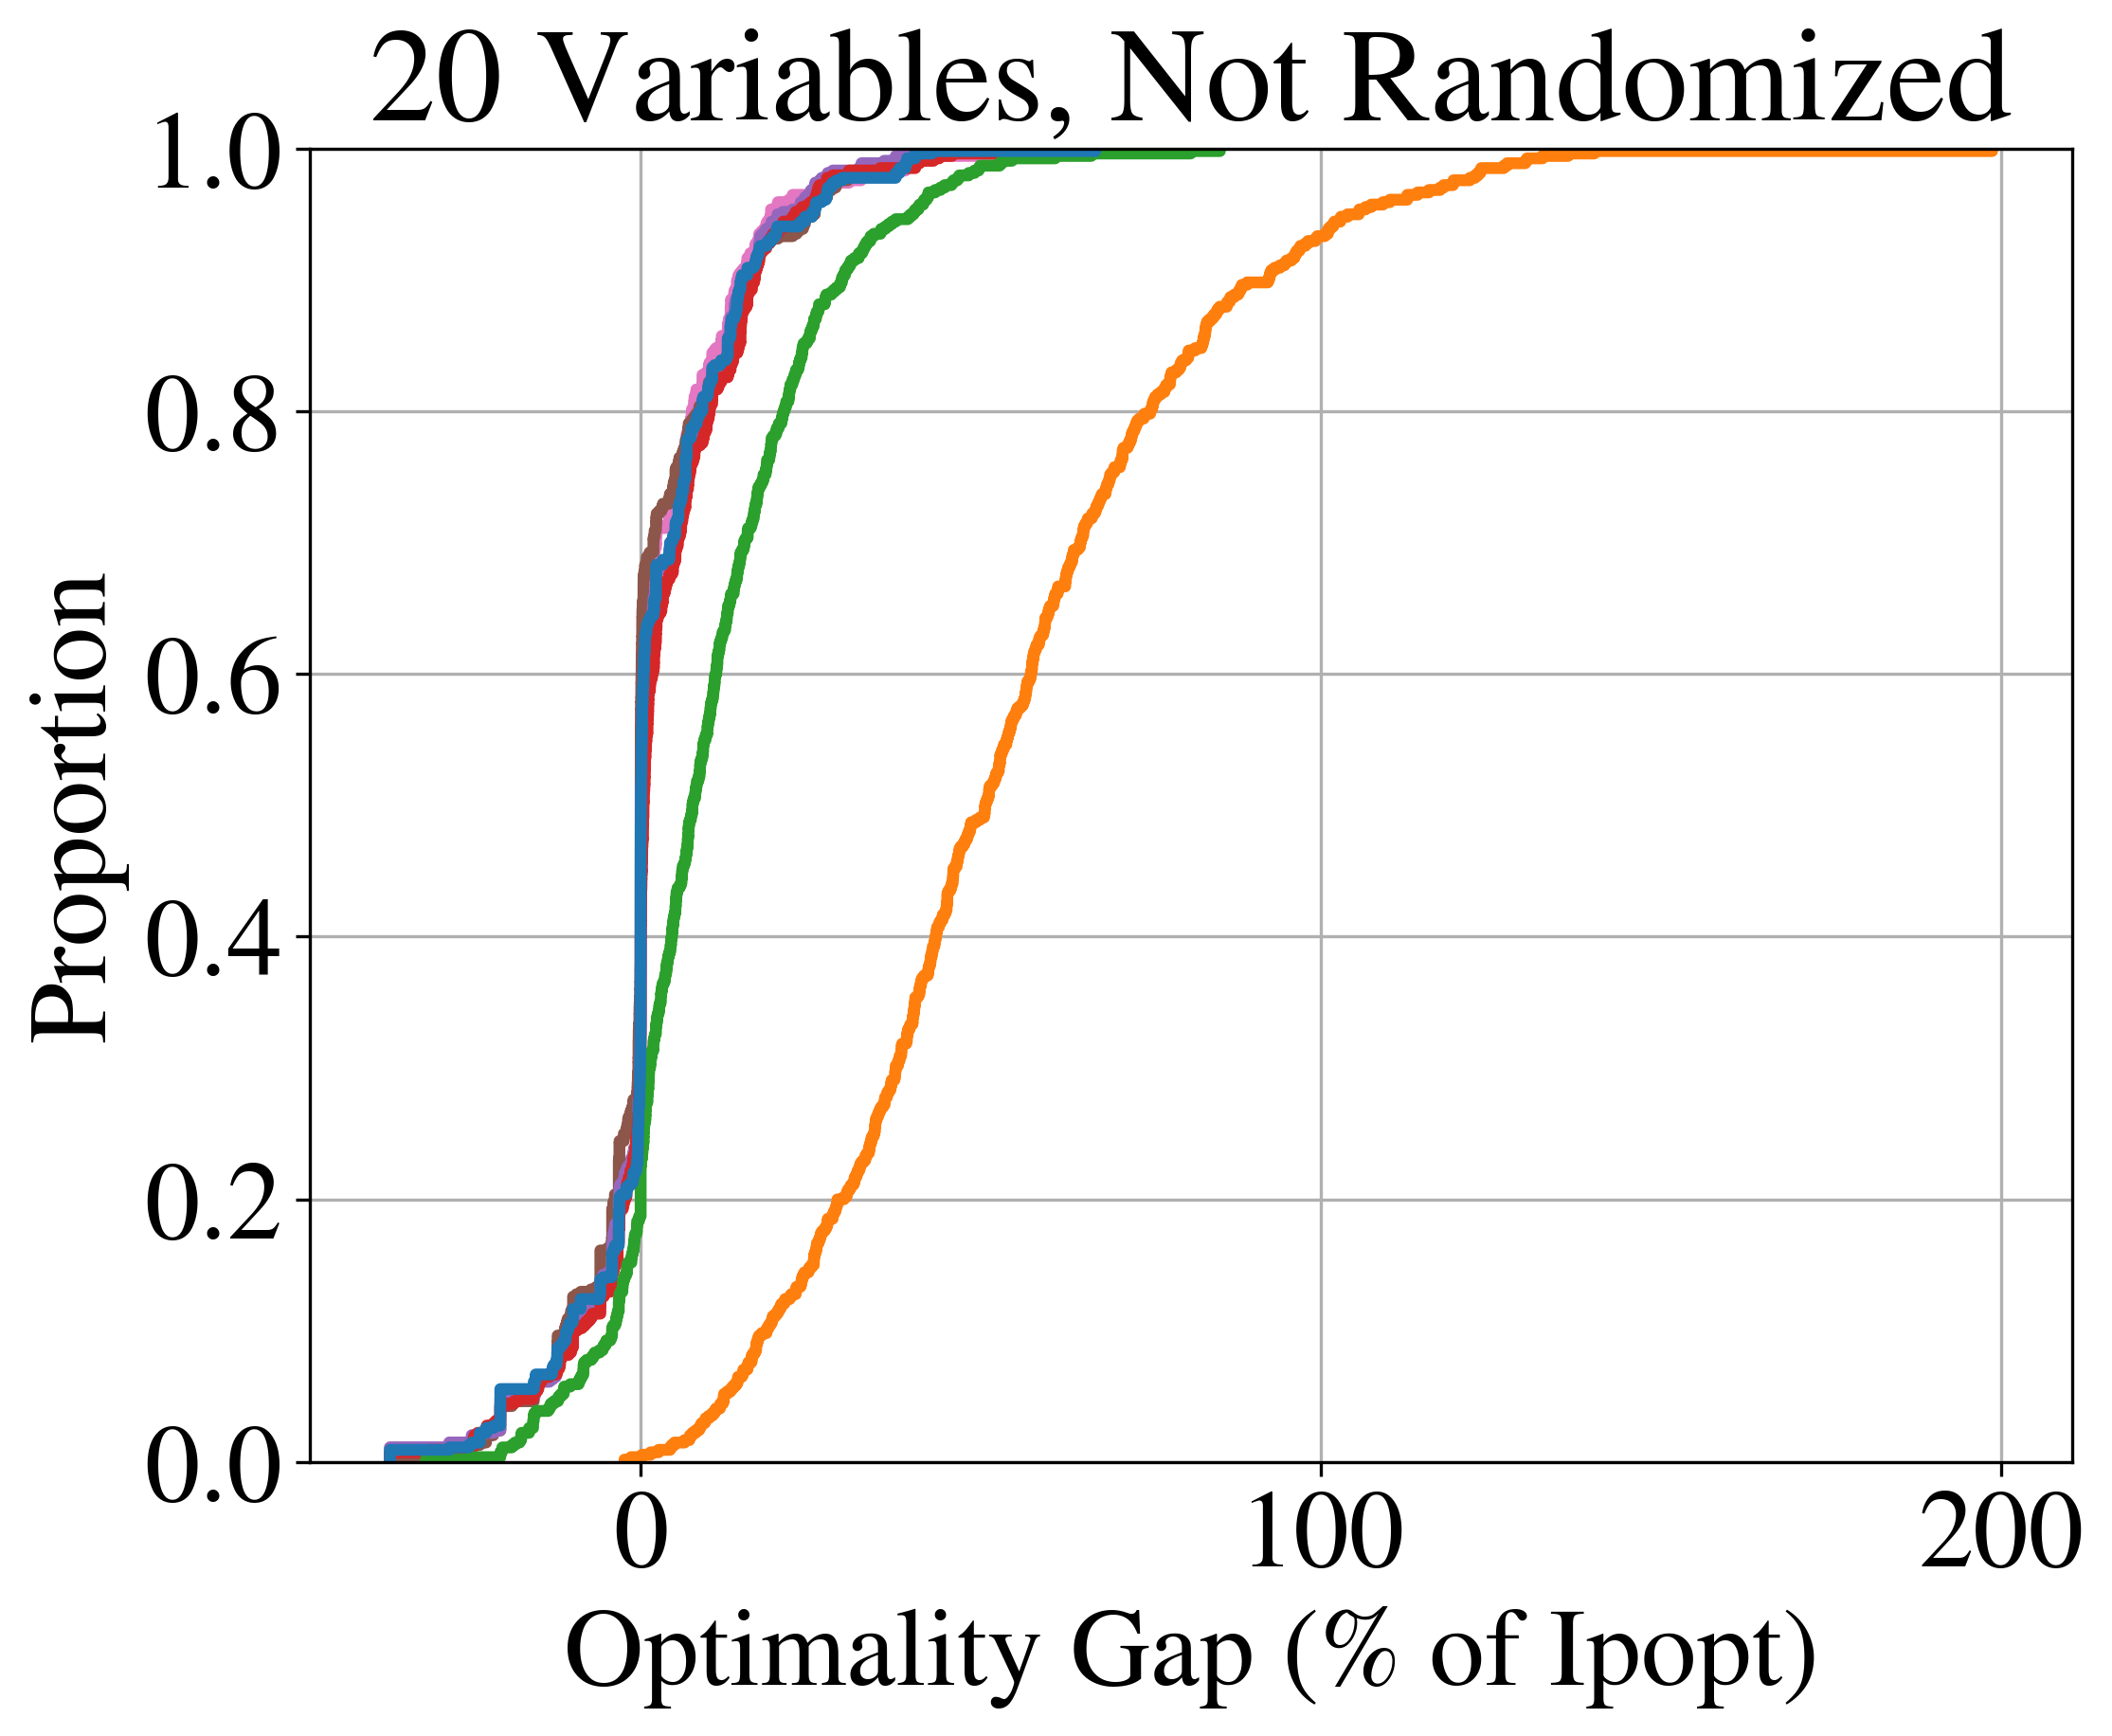

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os
sys.path.insert(0, os.environ['PLOT_SETTINGS_DIR'])
import plot_settings

df = pd.concat([
    pd.read_csv("data/qcqp1_experiment_new_distance.csv"),
    pd.read_csv("data/qcqp1_experiment_new_distance_lower_q.csv")
    ])

df['variables'] = df['benchmark'].str.extract(r'_c_(\d+)').astype(int)
df['constraints'] =  df['benchmark'].str.extract(r'_c_\d+_(\d+)').astype(int)
df['gap'] =  (df['objective'] - df['ipopt_objective']) / np.abs(df['ipopt_objective']) * 100
df = df.sort_values(by='bits')
print(df.columns)
df['Bits'] = df['bits'].replace(0, '64')
for i, ((v, r), sdf)in enumerate(df.groupby(['variables', 'random'])):
    fig, ax = plt.subplots(figsize=(8,6))
    
    sns.ecdfplot(sdf, 
                 ax=ax,
                 x='gap', hue='Bits', palette='tab10', 
                 linewidth=3,
                 legend=i==0)
    ax.grid()
    # if i == 0:
    #     ax.legend(title='Bits', fontsize=24)
    ax.set_title(f'{v} Variables, {"Not " if r else ""}Randomized')
    ax.set_xlabel('Optimality Gap (% of Ipopt)')
    fig.savefig(f'delay_v{i}.pdf', bbox_inches='tight')
    # if i != 
# df.variables

Index(['benchmark', 'bits', 'distance', 'dual_status', 'ipopt_objective',
       'objective', 'primal_status', 'random', 'time', 'variables',
       'constraints', 'gap'],
      dtype='object')


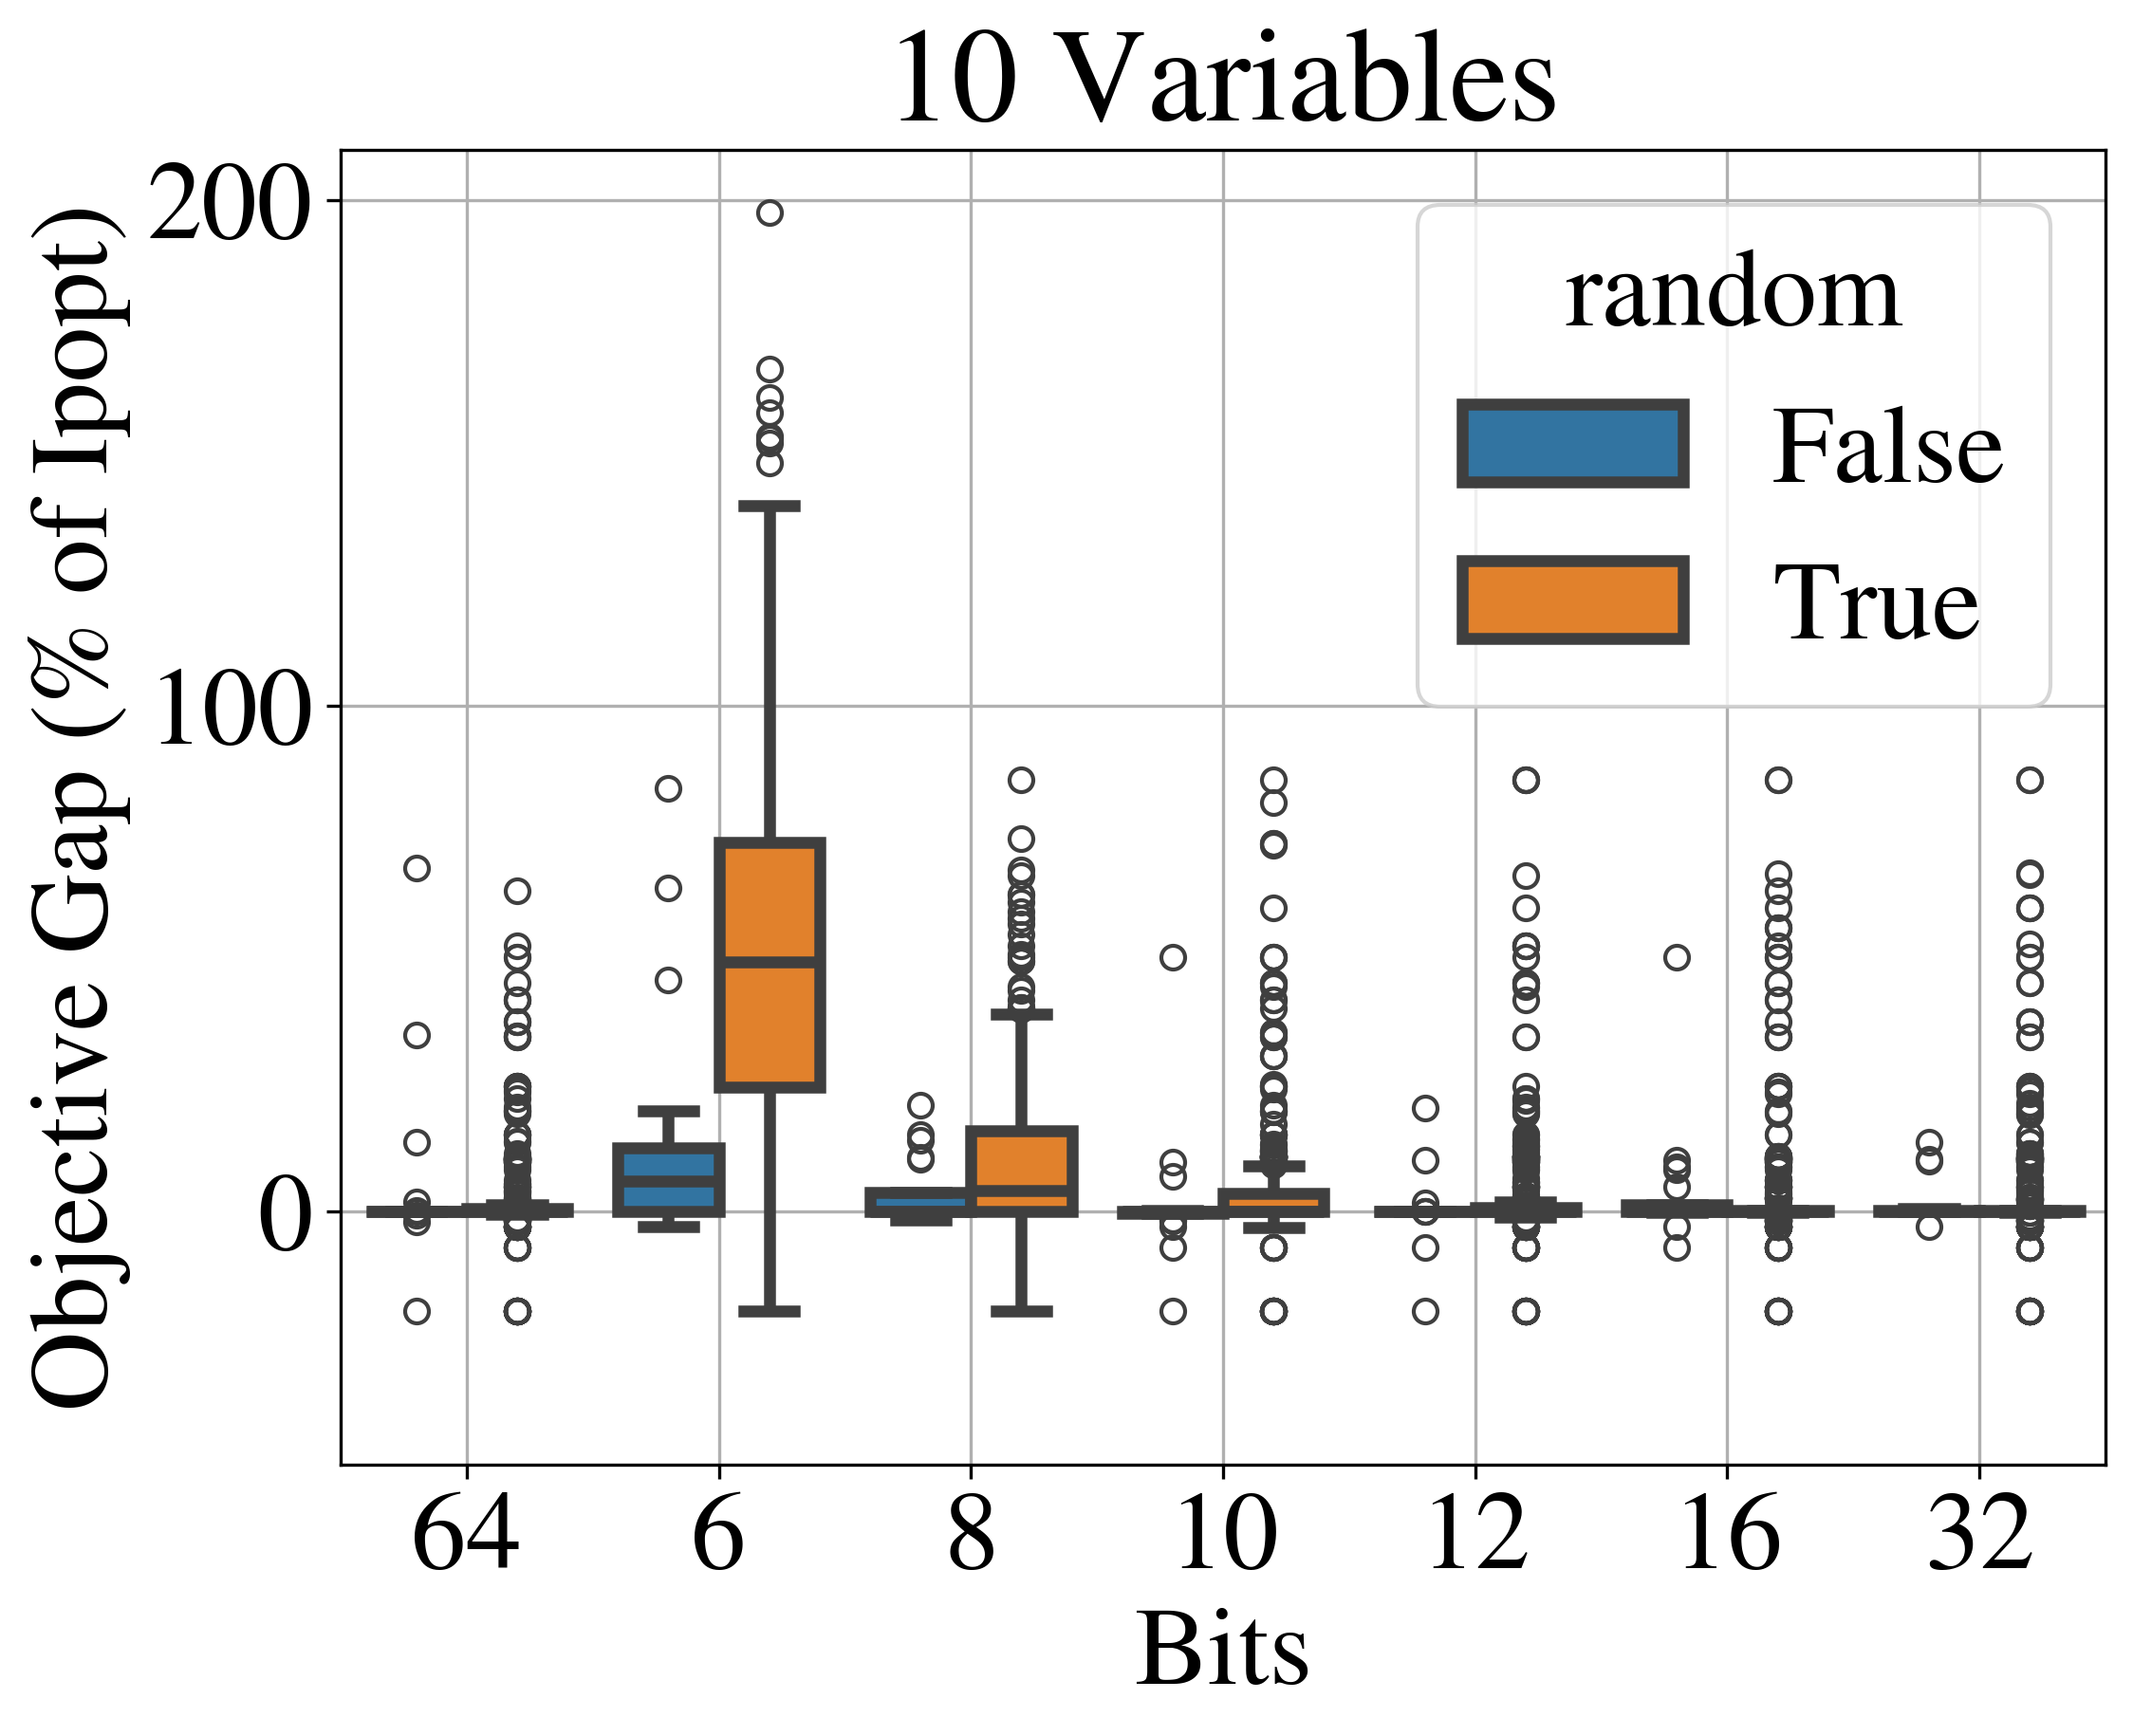

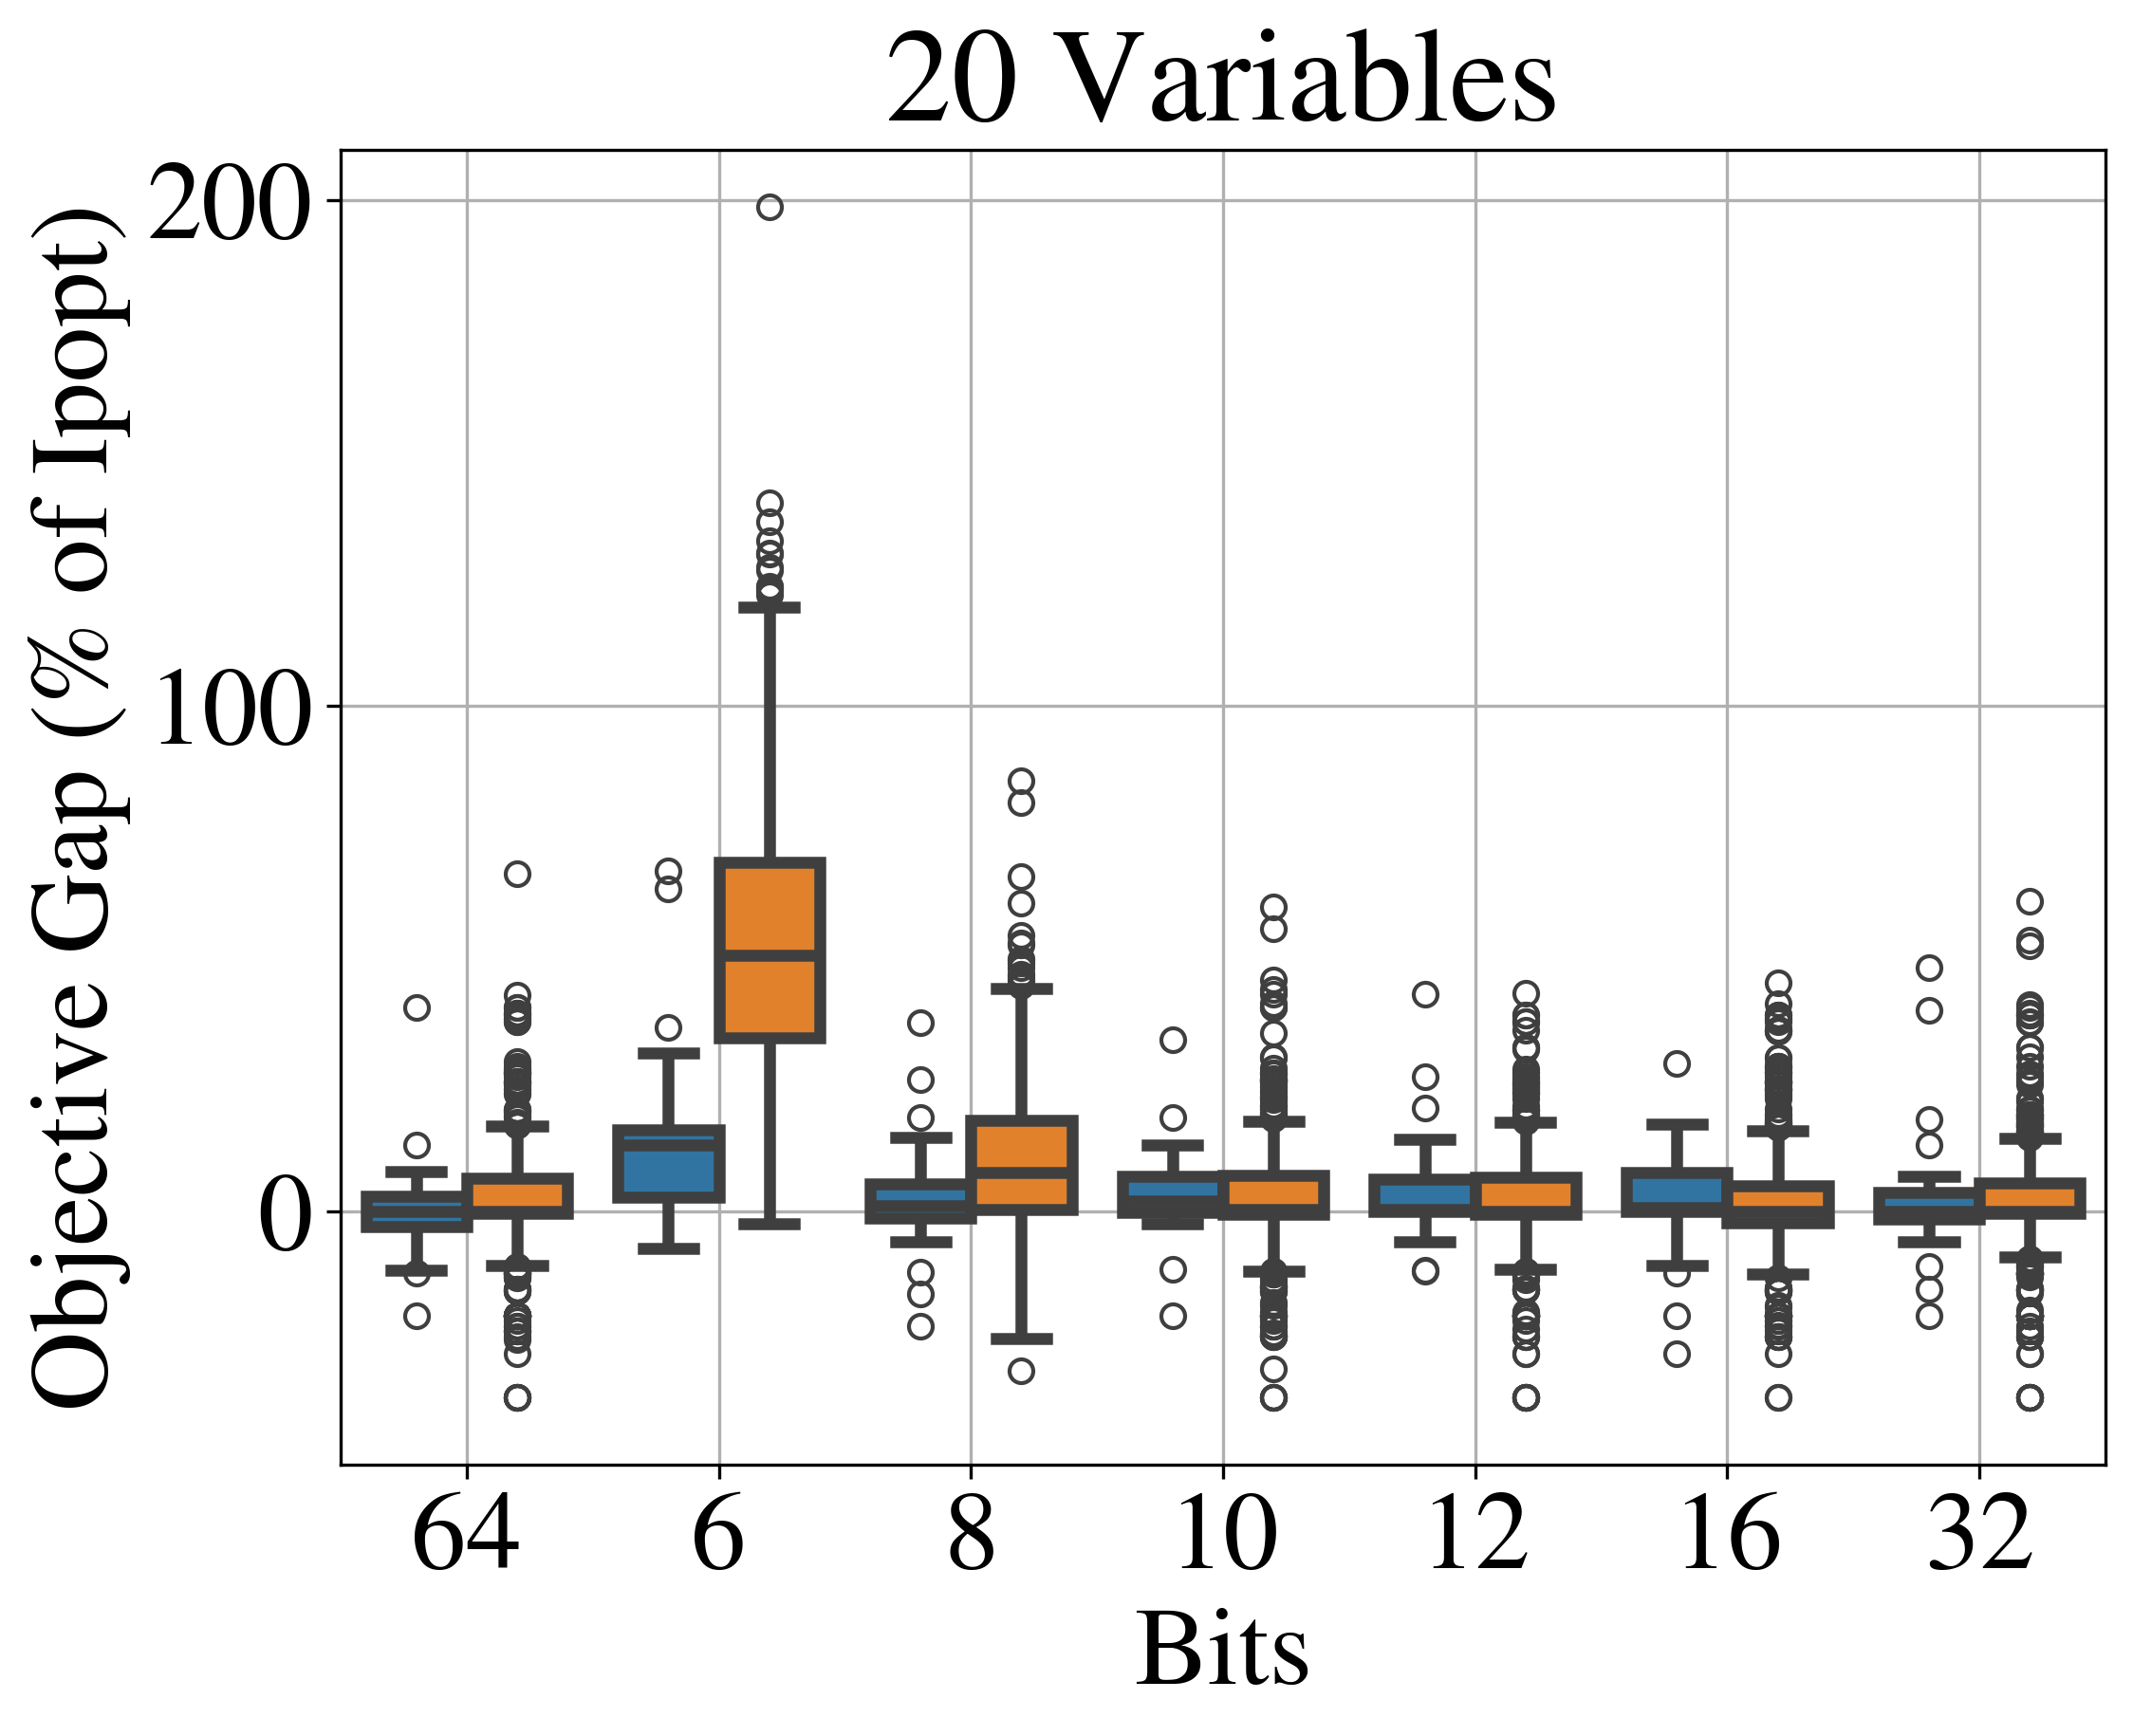

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os
sys.path.insert(0, os.environ['PLOT_SETTINGS_DIR'])
import plot_settings

df = pd.concat([
    pd.read_csv("data/qcqp1_experiment_new_distance.csv"),
    pd.read_csv("data/qcqp1_experiment_new_distance_lower_q.csv")
    ])

df['variables'] = df['benchmark'].str.extract(r'_c_(\d+)').astype(int)
df['constraints'] =  df['benchmark'].str.extract(r'_c_\d+_(\d+)').astype(int)
df['gap'] =  (df['objective'] - df['ipopt_objective']) / np.abs(df['ipopt_objective']) * 100
df = df.sort_values(by='bits')
print(df.columns)
df['Bits'] = df['bits'].replace(0, '64')
for i, ((v,), sdf)in enumerate(df.groupby(['variables'])):
    fig, ax = plt.subplots(figsize=(8,6))
    
    sns.boxplot(sdf, 
                 ax=ax,
                 y='gap', x='Bits', hue='random', palette='tab10', 
                 linewidth=3,
                 legend=i==0)
    ax.grid()
    ax.set_ylim(-50, 210)
    # if i == 0:
    #     ax.legend(title='Bits', fontsize=24)
    ax.set_title(f'{v} Variables')
    ax.set_ylabel('Objective Gap (% of Ipopt)') 
    fig.savefig(f'quant_{v}.pdf', bbox_inches='tight')
    # if i != 
# df.variables

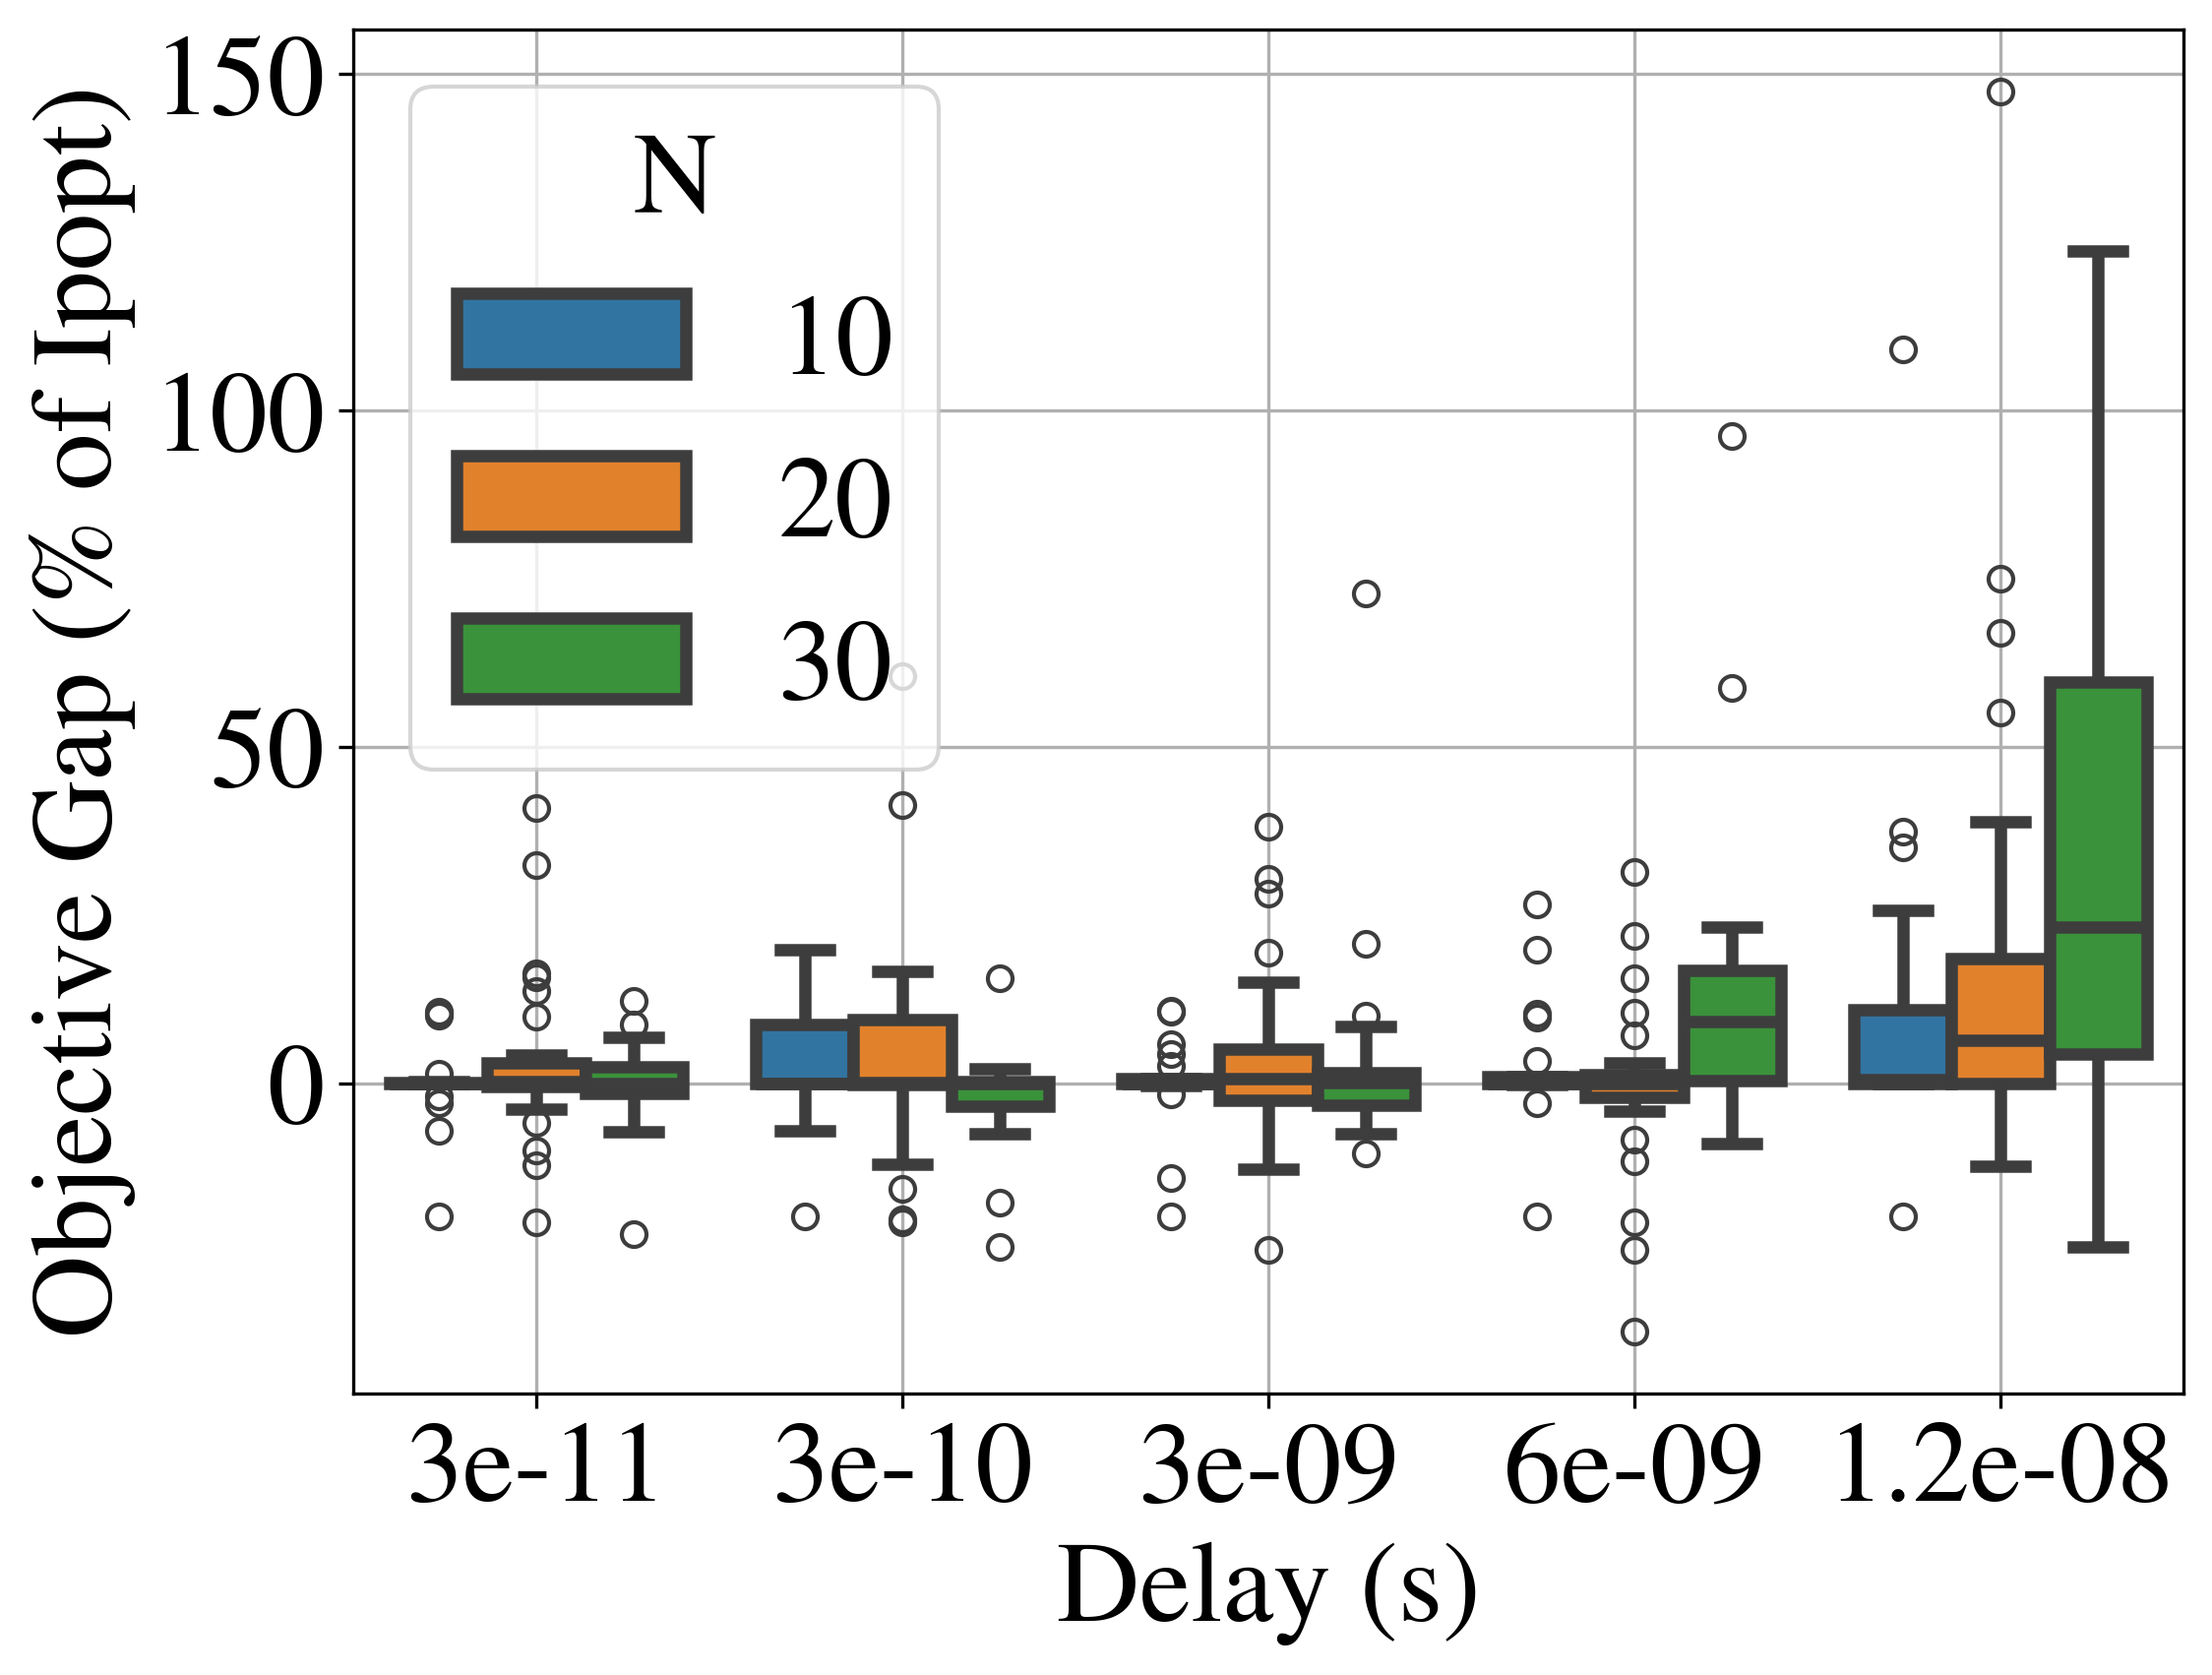

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.concat([
    pd.read_csv("data/qcqp1_experiment_delay.csv"),
    pd.read_csv("data/qcqp1_experiment_delay_30.csv")
    ])
df['Delay (s)'] = 3e-8 * df['delay']
df['variables'] = df['benchmark'].str.extract(r'_c_(\d+)').astype(int)
df['constraints'] =  df['benchmark'].str.extract(r'_c_\d+_(\d+)').astype(int)
df['gap'] =  (df['objective'] - df['ipopt_objective']) / np.abs(df['ipopt_objective']) * 100
# for i, ((v,), sdf)in enumerate(df.groupby(['variables'])):
fig, ax = plt.subplots(figsize=(8,6))
    
sns.boxplot(df, 
                ax=ax,
                y='gap', x='Delay (s)', hue='variables', palette='tab10', 
                linewidth=3)
ax.legend(title='N')
ax.grid()
# if i == 0:

#     ax.legend(title='Bits', fontsize=24)
# ax.set_title(f'{v} Variables')
ax.set_ylabel('Objective Gap (% of Ipopt)')
# ax.set_ylabel('Optimality Gap (% of Ipopt)')
fig.savefig(f'delay_plot.pdf', bbox_inches='tight')
    # if i != 
# df.variables
# mean_df = 